# Install locally 
- samtools
- igvtools
```bash
sudo apt install -y default-jre

cd ~/myworkdir/tools
wget https://data.broadinstitute.org/igv/projects/downloads/2.19/IGV_2.19.8.zip
ls -la IGV_2.19.8.zip   # confirm it actually downloaded (should be tens of MB, not an error page)
unzip IGV_2.19.8.zip
cd IGV_2.19.8
ls
chmod +x igvtools

export JAVA_HOME=$HOME/myworkdir/tools/IGV_Linux_2.19.8/jdk-21
export PATH=$JAVA_HOME/bin:$PATH

java -version    # confirm it now shows 21.x
./igvtools version


echo 'export JAVA_HOME=$HOME/myworkdir/tools/IGV_Linux_2.19.8/jdk-21' >> ~/.bashrc
echo 'export PATH=$JAVA_HOME/bin:$HOME/myworkdir/tools/IGV_2.19.8:$PATH' >> ~/.bashrc
source ~/.bashrc

cd /tmp
igvtools version 
```

In [1]:
import pysam
import pandas as pd
from collections import defaultdict
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
import subprocess
from collections import defaultdict
import numpy as np


In [ ]:
TAF1_START_END = "71366357-71466005" # refseq igv
TAF1_START_END_W = "71366000-71467000" # bigger window arounf TAF1 to extrast subset of bam
TAF1_EXON32_START_END = "71424154-71424238" # refseq igv
TAF1_INTRON32_START_END = "71424239-71454169" # refseq igv
TAF1_EXON33_START_END = "71454170-71454237" # refseq igv

EXON32_LAST_BP    = int(TAF1_EXON32_START_END.split("-")[1])
INTRON32_FIRST_BP = int(TAF1_INTRON32_START_END.split("-")[0])
INTRON32_LAST_BP  = int(TAF1_INTRON32_START_END.split("-")[1])
EXON33_START_BP   = int(TAF1_EXON33_START_END.split("-")[0])
EXON33_END_BP     = int(TAF1_EXON33_START_END.split("-")[1])
EXON38_END_BP     = int(TAF1_START_END.split("-")[1])
INTRON_LENGHT     = int(INTRON32_LAST_BP) - int(EXON32_LAST_BP) #29931
SVA_START_BP       = 71440512   # published start of the SVA insertion (= end of "pre" / 32i region)

TAF1_EXON32_INTRON32_JUNCTION_W = f"{int(EXON32_LAST_BP)-9}-{int(INTRON32_FIRST_BP)+9}" # 71424228-71424249

INTRON_LENGHT
TAF1_EXON32_INTRON32_JUNCTION_W

'71424229-71424248'

# Nucseq Data

The libraires mixes samples

In [3]:
df_meta = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/original_data/XDP dataset metadata - Gabri's Version.csv")
df_meta = df_meta[["donor_id", "original_donor_id"]].rename(columns={"donor_id": "new_donor_id"}).drop_duplicates()
df_meta

,new_donor_id,original_donor_id
0,SCF-22-054,SCF-22-054CM
1,SCF-23-075,SCF_23_075CM
2,SCF-22-067,SCF_22_067CM
3,SCF-23-079,SCF_23_079CF
4,SCF-22-065,SCF_22_065CM
5,SCF-23-072,SCF_23_072CF
6,SCF-22-050,SCF_22-050CM6
7,SCF-23-068,SCF-23-068CM
8,SCF-23-074,SCF_23_074CF
9,SCF-22-057,SCF_22-057CM


In [4]:
# Use the barcodes in processed adata
TISSUE = "Striatum"
nucseq = sc.read_h5ad(f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/{TISSUE}/{TISSUE}_combined_QC_mmc_ct-cured_zoned.h5ad", backed="r")
obs_nuc = nucseq.obs.copy()

# remvoe bad quality cells
obs_nuc = obs_nuc[~obs_nuc["ct_for_deg"].str.startswith("-")]  # assuming there is a column "ct_for_deg" indicating cell quality

# reconstruct original barcode (unique in a single library)
# need to merge with bam file
obs_nuc["original_barcode"] = obs_nuc["barcode"].apply(lambda x: x.split("__")[2])
obs_nuc["original_barcode"] =obs_nuc["original_barcode"].apply(lambda x: x.split("_")[0])
obs_nuc["original_library"] = obs_nuc["barcode"].apply(lambda x: x.split("__")[1])

# merge cell types
obs_nuc["ct_for_deg"] = (
    obs_nuc["ct_for_deg"]
    .astype(str)
    .replace({
        "Matrix_D1": "Matrix", 
        "Matrix_D2": "Matrix", 
        "Patch_D1": "Patch", 
        "Patch_D2": "Patch"
    })
    .fillna(obs_nuc["ct_for_deg"].astype(str))
    .astype("category")
)

# add unified donor id
obs_nuc = obs_nuc.merge(df_meta, how="left", left_on="donor_id", right_on="original_donor_id")
obs_nuc = obs_nuc.drop(columns=["donor_id", "original_donor_id"]).rename(columns={"new_donor_id": "donor_id"})
display(obs_nuc)
print("number of donors in obs_nuc:", obs_nuc.groupby("donor_id").ngroups)

# which libs have been used for the sample in this adata
nucseq_striatum_libs = obs_nuc["original_library"].unique().tolist()
nucseq_striatum_libs

,background_fraction,cell_probability,cell_size,droplet_efficiency,barcode,bcl,rna_index,library,library__barcode,frac_mito,...,is_neuron,mapping_coupling_for_zoning,zone,zone_probability,mapping_coupling_for_zoning_4_zones,zone_4,zone_4_probability,original_barcode,original_library,donor_id
0,0.003941,0.999955,15618.492188,2.163925,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GTAGGCCT...,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GTAGGCCT...,0.001627,...,False,Astrocyte,4,1.000,Astrocyte 4 zones,1,1.000,GTAGGCCTCCGTTGTC-1,pXDPsHSrPuiv1d240321rxn4,SCF-20-025
1,0.009691,0.999955,14187.895508,2.199903,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__TCGGGACT...,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__TCGGGACT...,0.000281,...,False,Astrocyte,6,0.855,Astrocyte 4 zones,2,0.740,TCGGGACTCTCTGTCG-1,pXDPsHSrPuiv1d240321rxn4,SCF-22-054
2,0.004581,0.999955,13582.982422,2.010379,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CGGGTCAC...,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CGGGTCAC...,0.000040,...,False,Astrocyte,6,0.517,Astrocyte 4 zones,2,0.999,CGGGTCACAAGAGGCT-1,pXDPsHSrPuiv1d240321rxn4,SCF-19-009
3,0.004263,0.999955,12883.346680,2.069477,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GGACATTG...,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GGACATTG...,0.000412,...,False,Astrocyte,5,0.993,Astrocyte 4 zones,2,0.951,GGACATTGTAAACCTC-1,pXDPsHSrPuiv1d240321rxn4,SCF-22-054
4,0.008720,0.999955,13293.195312,1.917607,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__ACGGAGAC...,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__ACGGAGAC...,0.000388,...,False,Astrocyte,NaN,0.863,Astrocyte 4 zones,2,0.924,ACGGAGACATACTACG-1,pXDPsHSrPuiv1d240321rxn4,SCF-20-025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215635,0.436521,0.999990,5263.216797,0.668542,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__CATG...,250328_SL-EXE_0516_A22N2VFLT4,SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__CATG...,0.000000,...,False,NaN,NaN,NaN,NaN,NaN,NaN,CATGAAGCAGGTGCGA-1,SI-TT-H12,SCF-22-050
215636,0.436829,0.999953,4984.368164,0.725044,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__GTGT...,250328_SL-EXE_0516_A22N2VFLT4,SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__GTGT...,0.000000,...,False,NaN,NaN,NaN,NaN,NaN,NaN,GTGTTACCAGGCTTCA-1,SI-TT-H12,SCF-22-060
215637,0.444862,0.999996,4720.072754,0.779890,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__ATAG...,250328_SL-EXE_0516_A22N2VFLT4,SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__ATAG...,0.001505,...,False,NaN,NaN,NaN,NaN,NaN,NaN,ATAGGCACACTAGTTA-1,SI-TT-H12,SCF-22-048
215638,0.409034,0.999988,4962.237793,0.720541,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__AGGG...,250328_SL-EXE_0516_A22N2VFLT4,SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__AGGG...,0.002831,...,False,NaN,NaN,NaN,NaN,NaN,NaN,AGGGCGTAGGTGCCCA-1,SI-TT-H12,SCF-23-083


number of donors in obs_nuc: 47


['pXDPsHSrPuiv1d240321rxn4',
 'pXDPsHSrPuiv1d240321rxn3',
 'pXDPsHSrPuiv1d240321rxn2',
 'pXDPsHSrPuiv1d240321rxn1',
 'pXDPsHSrCaiv1d240321rxn4',
 'pXDPsHSrCaiv1d240321rxn3',
 'pXDPsHSrCaiv1d240321rxn2',
 'pXDPsHSrCaiv1d240321rxn1',
 '241218_v2_10X-GEMX-5P_Ca_rxn1',
 '241218_v2_10X-GEMX-5P_Ca_rxn2',
 '241218_v2_10X-GEMX-5P_Pu_rxn1',
 '241218_v2_10X-GEMX-5P_Pu_rxn2',
 'SI-TT-H9',
 'SI-TT-H10',
 'SI-TT-H11',
 'SI-TT-H12']

In [5]:
# read here from where the .bam file are located
df_lib_nucseq = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/SlideTags_XDP_metadata/XDP Flowcell Tracker - freeze2.csv")

# select only the libraries that are in the nucseq_striatum_libs list
df_lib_nucseq = df_lib_nucseq[df_lib_nucseq["Library"].isin(nucseq_striatum_libs)]

df_lib_nucseq

,Library,BCL,RNA Index,Village / Cohort,Region,fastqs,cr,cb,ds,vireo,Distinct BCLS,Unnamed: 11
8,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3,SI-TT-C9,1,Pu,False,False,False,False,False,NaN,gs://macosko_data/libraries/A22KHKGLT3/pXDPsHS...
9,pXDPsHSrPuiv1d240321rxn3,A22KHKGLT3,SI-TT-D9,1,Pu,False,False,False,False,False,NaN,gs://macosko_data/libraries/A22KHKGLT3/pXDPsHS...
10,pXDPsHSrPuiv1d240321rxn2,A22KHKGLT3,SI-TT-E9,1,Pu,False,False,False,False,False,NaN,gs://macosko_data/libraries/A22KHKGLT3/pXDPsHS...
11,pXDPsHSrPuiv1d240321rxn1,A22KHKGLT3,SI-TT-F9,1,Pu,False,False,False,False,False,NaN,gs://macosko_data/libraries/A22KHKGLT3/pXDPsHS...
12,pXDPsHSrCaiv1d240321rxn4,A22KHKGLT3,SI-TT-G9,1,Ca,False,False,False,False,False,NaN,gs://macosko_data/libraries/A22KHKGLT3/pXDPsHS...
13,pXDPsHSrCaiv1d240321rxn3,A22KHKGLT3,SI-TT-H9,1,Ca,False,False,False,False,False,NaN,gs://macosko_data/libraries/A22KHKGLT3/pXDPsHS...
14,pXDPsHSrCaiv1d240321rxn2,A22KHKGLT3,SI-TT-A10,1,Ca,False,False,False,False,False,NaN,gs://macosko_data/libraries/A22KHKGLT3/pXDPsHS...
15,pXDPsHSrCaiv1d240321rxn1,A22KHKGLT3,SI-TT-B10,1,Ca,False,False,False,False,False,NaN,gs://macosko_data/libraries/A22KHKGLT3/pXDPsHS...
16,241218_v2_10X-GEMX-5P_Ca_rxn1,250117_SL-EXL_0041_A22LHCHLT4,SI-TT-F4,2,Ca,True,True,True,True,False,NaN,gs://macosko_data/libraries/250117_SL-EXL_0041...
17,241218_v2_10X-GEMX-5P_Ca_rxn2,250117_SL-EXL_0041_A22LHCHLT4,SI-TT-F5,2,Ca,True,True,True,True,False,NaN,gs://macosko_data/libraries/250117_SL-EXL_0041...


# Calcualte 32i 

*) Read
- blocks: a block is a tuple (start, end) that tell in the genome where a subset of the read have been aligned
    - ex. a read of a spliced rna will have 2 blocks (i, endexon 1), (start exon 2, j)

- cigartuple: list of (operation, length) (one for each block), that tell how the read bases in that blcok have been aligned

In [6]:
def overlaps_window(read, win_start, win_end):
    # checks whether any aligned block of a read overlaps [win_start, win_end]

    # attetion, need to conver base 0
    win_start0, win_end0 = win_start - 1, win_end - 1
    for block_start, block_end in read.get_blocks():
        if block_start < win_end0 and block_end > win_start0:
            return True
    return False

def has_canonical_splice(read, gap):
    #returns True if the read contains a splice gap of exactly 29,931 bp 
    # the canonical exon32→exon33 intron length
    if read.cigartuples is None:
        return False
    # attention op=3 encode "N" (skipped region from the reference)
    return any(op == 3 and length == gap for op, length in read.cigartuples)


In [7]:

PRE_START, PRE_END   = INTRON32_FIRST_BP, SVA_START_BP     # 32i intron pile-up region
POST_START, POST_END = EXON33_START_BP, int(TAF1_START_END.split("-")[1])     # downstream normal transcript
CANONICAL_SPLICE_LEN = EXON33_START_BP - EXON32_LAST_BP - 1   # 29931

per_cell_results = []   # one row per (library, cell) instead of one row per library

for _, row in df_lib_nucseq.iterrows():

    # select the library --> so we can take the relative BAM
    lib, bcl, rna_index = row["Library"], row["BCL"], row["RNA Index"]
    print(lib)

    # called cells for this library from curated adata
    CALLED_CELLS = set(obs_nuc.loc[obs_nuc["original_library"] == lib, "original_barcode"])
    # save this barcodes
    TMP_BC_FILE = Path("/home/gdallagl/myworkdir/XDP/data/_old/called_cells.txt")
    with open(TMP_BC_FILE, "w") as f:
        for cell in CALLED_CELLS:
            f.write(f"{cell}\n")

    # where to save bam file locally
    save_folder = f"$HOME/myworkdir/XDP/data/XDP/NucSec/NucSeq_single_libraries/{bcl}/{rna_index}/bam"
    # where is the file in the cloud (GCP bucket)
    bam = f"gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/gene-expression/{bcl}/{rna_index}/outs/possorted_genome_bam.bam"

    script = f"""
        set -e

        export GCS_OAUTH_TOKEN=$(gcloud auth print-access-token)

        BAM="{bam}"
        SAVE_FOLDER="{save_folder}"
        mkdir -p "$SAVE_FOLDER"
        cd "$SAVE_FOLDER"

        # view --> subset
        # -b --> ouput bam
        # -q 30 --> only reads with MAPQ >= 30
        # -F 0x904 --> exclude unmapped, secondary, supplementary reads
        # -D CB:"{TMP_BC_FILE}" --> only reads with CB in the list of barcodes in the file
        # chrX:{TAF1_START_END_W} --> only reads mapping to chrX in the TAF1 region
        samtools view \\
          -b \\
          -q 30 -F 0x904 \\
          -D CB:"{TMP_BC_FILE}" \\
          "$BAM" \\
          chrX:{TAF1_START_END_W} \\
          -o taf1_subset.bam
        
        # name .bai
        samtools index taf1_subset.bam
    """

    # Run the scirpt
    proc = subprocess.run(["bash", "-c", script], capture_output=True, text=True)
    if proc.returncode != 0:
        print(f"FAILED (subset step): {lib}\n{proc.stderr}")
        continue

    # path to the subset bam file (local)
    subset_bam_path = f"{save_folder.replace('$HOME', str(Path.home()))}/taf1_subset.bam"

    # -----------------------------------------------------------------
    # UMI counting, PER CELL -- dict of CB -> set of UMIs instead of one
    # pooled set, so this can be pseudobulked by sample/cell type downstream
    # -----------------------------------------------------------------

    # create a on obj from the bam file to query
    bam_fh = pysam.AlignmentFile(subset_bam_path, "rb") # needs .bai in same folder

    # add dict that store UMI per cell 
    # dict[cell] = {set of UMIs} --> set allow deduplication of UMIs
    pre_umis_per_cell = defaultdict(set)
    post_umis_per_cell = defaultdict(set)

    # seach for reads falling in PRE
    for read in bam_fh.fetch("chrX", PRE_START, PRE_END):
        # fecth returns all reads that 
            # are in the region "chrX"
            # have at least one aligned block overlapping [PRE_START, PRE_END]

        # if read in bad qulity, skip it
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue

        # CB = cell barcode, UB = UMI barcode (Tags from cell ranger)
        # if the read does not have CB or UB, skip it
        if not (read.has_tag("CB") and read.has_tag("UB")):
            continue

        #  read have an actual aligned base — not just span — physically inside [PRE_START, PRE_END]
        if not overlaps_window(read, PRE_START, PRE_END):
            continue

        # Catches the remaining edge case: a read whose CIGAR contains the exact 29,931bp exon32→33 splice gap and happens to have a real aligned block landing inside the pre-window right at its edge (e.g. a few bases of exon32 itself, which sits right before PRE_START). That's a completely normal, correctly-spliced transcript — not retention evidence — so it's excluded even though it passed the two checks above.
        if has_canonical_splice(read, gap=CANONICAL_SPLICE_LEN):
            continue  # normal spliced transcript, not 32i pile-up

        # if read survived
        # add it to the dict: key is cell barcode, value is the UMI
        pre_umis_per_cell[read.get_tag("CB")].add(read.get_tag("UB"))

    # seach for reads falling in POST
    # same as before but
        # differt window
        # do not filter eprfect splice
    for read in bam_fh.fetch("chrX", POST_START, POST_END):
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        if not (read.has_tag("CB") and read.has_tag("UB")):
            continue
        if not overlaps_window(read, POST_START, POST_END):
            continue
        post_umis_per_cell[read.get_tag("CB")].add(read.get_tag("UB"))

    # close the obj
    bam_fh.close()


    # Create rows of the df
    # one row per called cell with any pre/post coverage; cells with zero of both
    # never show up here -- left as absent rather than 0, fill in after merging
    # onto obs_nuc if you want explicit zeros for the pseudobulk
    for cb in set(pre_umis_per_cell) | set(post_umis_per_cell):
        per_cell_results.append({
            "original_barcode": cb,
            "library": lib,
            "bcl": bcl,
            "rna_index": rna_index,
            "n_pre_umis": len(pre_umis_per_cell.get(cb, set())),
            "n_post_umis": len(post_umis_per_cell.get(cb, set())),
        })

# df_cell_metrics_nuc only has a row for a cell if it had at least one qualifying read in the pre- or post-window (built via set(pre_umis_per_cell) | set(post_umis_per_cell)
df_cell_metrics_nuc = pd.DataFrame(per_cell_results)


df_cell_metrics_nuc["library__barcode"] = (
    df_cell_metrics_nuc["bcl"].astype(str) + "__" + 
    df_cell_metrics_nuc["library"].astype(str) + "__" + 
    df_cell_metrics_nuc["original_barcode"].astype(str)
)

df_cell_metrics_nuc




pXDPsHSrPuiv1d240321rxn4
pXDPsHSrPuiv1d240321rxn3
pXDPsHSrPuiv1d240321rxn2
pXDPsHSrPuiv1d240321rxn1
pXDPsHSrCaiv1d240321rxn4
pXDPsHSrCaiv1d240321rxn3
pXDPsHSrCaiv1d240321rxn2
pXDPsHSrCaiv1d240321rxn1
241218_v2_10X-GEMX-5P_Ca_rxn1
241218_v2_10X-GEMX-5P_Ca_rxn2
241218_v2_10X-GEMX-5P_Pu_rxn1
241218_v2_10X-GEMX-5P_Pu_rxn2
SI-TT-H9
SI-TT-H10
SI-TT-H11
SI-TT-H12


,original_barcode,library,bcl,rna_index,n_pre_umis,n_post_umis,library__barcode
0,CACCAGGCAGAAGCAC-1,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3,SI-TT-C9,1,0,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CACCAGGC...
1,CCTAGCTAGCCCAATT-1,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3,SI-TT-C9,1,0,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CCTAGCTA...
2,TCTGGAAAGTACGATA-1,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3,SI-TT-C9,1,2,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__TCTGGAAA...
3,GCCAAATAGTGCGATG-1,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3,SI-TT-C9,2,1,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GCCAAATA...
4,GACGTTACAAAGCGGT-1,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3,SI-TT-C9,1,0,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GACGTTAC...
...,...,...,...,...,...,...,...
78941,CTCCTACCACTCACCT-1,SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4,SI-TT-H12,3,0,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__CTCC...
78942,ACACGCCCAAGCGCAG-1,SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4,SI-TT-H12,0,1,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__ACAC...
78943,CCTGTGGAGCCGGATT-1,SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4,SI-TT-H12,3,0,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__CCTG...
78944,GCGCTCAAGATCGCGT-1,SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4,SI-TT-H12,0,2,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__GCGC...


In [8]:
# Create PER cell df

# subset
obs_nuc_sub = obs_nuc[["library__barcode", "condition", "ct_for_deg", "donor_id"]].copy()
# add to each cell the number of pre/post UMIs counted in the bam file
obs_nuc_sub = obs_nuc_sub.merge(df_cell_metrics_nuc, on="library__barcode", how="left")
# fill with 0 for cells that had no reads in the pre/post windows (legitimate zero counts)
obs_nuc_sub[["n_pre_umis", "n_post_umis"]] = obs_nuc_sub[["n_pre_umis", "n_post_umis"]].fillna(0)

# define metrix ratio
obs_nuc_sub["pileup_metric"] = obs_nuc_sub["n_pre_umis"] / (obs_nuc_sub["n_pre_umis"] + obs_nuc_sub["n_post_umis"])

# define matrix ratio normalized by the width of the pre/post windows
pre_width = int(SVA_START_BP) - int(INTRON32_FIRST_BP)
post_width = int(POST_END) - int(POST_START)   # must match the window n_post_umis was counted over
obs_nuc_sub["pre_density"] = obs_nuc_sub["n_pre_umis"] / pre_width
obs_nuc_sub["post_density"] = obs_nuc_sub["n_post_umis"] / post_width
obs_nuc_sub["pileup_metric_norm"] = obs_nuc_sub["pre_density"] / (obs_nuc_sub["pre_density"] + obs_nuc_sub["post_density"])

# remove bad samples
# obs_nuc_sub = obs_nuc_sub[~(obs_nuc_sub["donor_id"]=="unassigned")]
# obs_nuc_sub["donor_id"] = obs_nuc_sub["donor_id"].astype("category").cat.remove_categories("unassigned")

obs_nuc_sub.to_csv(f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/32i/32i_per_cell_{TISSUE}.csv", index=False)

obs_nuc_sub


,library__barcode,condition,ct_for_deg,donor_id,original_barcode,library,bcl,rna_index,n_pre_umis,n_post_umis,pileup_metric,pre_density,post_density,pileup_metric_norm
0,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GTAGGCCT...,XDP,Astrocyte,SCF-20-025,GTAGGCCTCCGTTGTC-1,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3,SI-TT-C9,2.0,0.0,1.0,0.000131,0.0,1.0
1,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__TCGGGACT...,Control,Astrocyte,SCF-22-054,TCGGGACTCTCTGTCG-1,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3,SI-TT-C9,1.0,0.0,1.0,0.000066,0.0,1.0
2,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CGGGTCAC...,XDP,Astrocyte,SCF-19-009,CGGGTCACAAGAGGCT-1,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3,SI-TT-C9,1.0,0.0,1.0,0.000066,0.0,1.0
3,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GGACATTG...,Control,Astrocyte,SCF-22-054,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.000000,0.0,NaN
4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__ACGGAGAC...,XDP,Astrocyte,SCF-20-025,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.000000,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215635,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__CATG...,Control,Oligodendrocyte,SCF-22-050,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.000000,0.0,NaN
215636,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__GTGT...,XDP,Oligodendrocyte,SCF-22-060,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.000000,0.0,NaN
215637,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__ATAG...,XDP,Oligodendrocyte,SCF-22-048,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.000000,0.0,NaN
215638,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__AGGG...,XDP,Oligodendrocyte,SCF-23-083,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.000000,0.0,NaN


In [21]:
# create per DONOR-CT df

all_pseudobulk = []

cell_types = ["Matrix", "Patch", "eMSN_D1D2", "eMSN_NUDAP", "non-MSN", "Oligodendrocyte", "OPC", "Astrocyte", "Microglia"]

for ct in cell_types:

    #subset to this ct
    tmp = obs_nuc_sub[obs_nuc_sub["ct_for_deg"] == ct].copy()

    # sum umis in same donor-ct
    tmp_pseudobulk = tmp.groupby("donor_id")[["n_pre_umis", "n_post_umis"]].sum()

    # add condition
    tmp_pseudobulk = tmp_pseudobulk.merge(
        tmp[["donor_id", "condition"]].drop_duplicates("donor_id"),
        on="donor_id", how="left",
    )

    # calcualte emtrics
    tmp_pseudobulk["pileup_metric"] = tmp_pseudobulk["n_pre_umis"] / (tmp_pseudobulk["n_pre_umis"] + tmp_pseudobulk["n_post_umis"])
    tmp_pseudobulk["pre_density"] = tmp_pseudobulk["n_pre_umis"] / pre_width
    tmp_pseudobulk["post_density"] = tmp_pseudobulk["n_post_umis"] / post_width
    tmp_pseudobulk["pileup_metric_norm"] = tmp_pseudobulk["pre_density"] / (tmp_pseudobulk["pre_density"] + tmp_pseudobulk["post_density"])

    tmp_pseudobulk["ct_for_deg"] = ct
    all_pseudobulk.append(tmp_pseudobulk)



df_pseudobulk_all = pd.concat(all_pseudobulk, ignore_index=True)

df_pseudobulk_all["ct"] = df_pseudobulk_all["ct_for_deg"].map({
    "Matrix": "Neuron",
    "Patch": "Neuron",
    "eMSN_D1D2": "Neuron",
    "eMSN_NUDAP": "Neuron",
    "non-MSN": "Neuron",
    "eMSN_StrioMat": "Neuron",
    "Oligodendrocyte": "Glia",
    "OPC": "Glia",
    "Astrocyte": "Glia",
    "Microglia": "Glia"
})

df_pseudobulk_all.to_csv(f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/32i/32i_per_donor_{TISSUE}.csv", index=False)

display(df_pseudobulk_all)

,donor_id,n_pre_umis,n_post_umis,condition,pileup_metric,pre_density,post_density,pileup_metric_norm,ct_for_deg,ct
0,PCMC-16-011,46.0,53.0,XDP,0.464646,0.003014,0.004478,0.402316,Matrix,Neuron
1,PCMC-16-012,26.0,55.0,XDP,0.320988,0.001704,0.004647,0.268271,Matrix,Neuron
2,SCF-18-003,109.0,176.0,XDP,0.382456,0.007143,0.014871,0.324469,Matrix,Neuron
3,SCF-18-004,32.0,51.0,XDP,0.385542,0.002097,0.004309,0.327335,Matrix,Neuron
4,SCF-18-006,116.0,258.0,XDP,0.310160,0.007602,0.021800,0.258545,Matrix,Neuron
...,...,...,...,...,...,...,...,...,...,...
418,SCF-23-075,57.0,63.0,Control,0.475000,0.003735,0.005323,0.412350,Microglia,Glia
419,SCF-23-079,91.0,95.0,Control,0.489247,0.005963,0.008027,0.426244,Microglia,Glia
420,SCF-23-080,58.0,25.0,XDP,0.698795,0.003801,0.002112,0.642767,Microglia,Glia
421,SCF-23-081,11.0,15.0,Control,0.423077,0.000721,0.001267,0.362546,Microglia,Glia


# Quanitty 32i

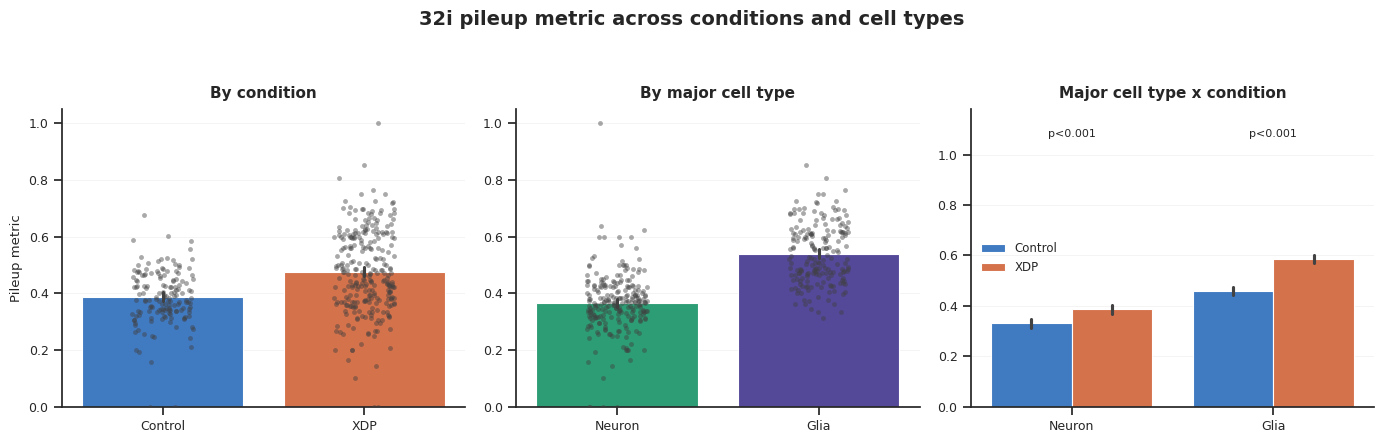

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# fixed categorical color assignments — validated colorblind-safe pairs, never cycled
CONDITION_COLORS = {"Control": "#2a78d6", "XDP": "#eb6834"}   # blue / orange
CT_COLORS        = {"Neuron": "#1baf7a", "Glia": "#4a3aa7"}   # aqua / violet — distinct from condition slots

sns.set_theme(style="ticks", context="notebook")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4.2))


def style_ax(ax, title, ylabel=None):
    ax.set_title(title, fontsize=11, fontweight="semibold", pad=8)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel if ylabel else "", fontsize=9.5)
    ax.tick_params(labelsize=9)
    ax.grid(axis="y", linewidth=0.5, alpha=0.3)
    sns.despine(ax=ax)


def annotate_sig(ax, data, x, order, g1="Control", g2="XDP"):
    y_max, y_min = data["pileup_metric"].max(), data["pileup_metric"].min()
    offset = (y_max - y_min) * 0.06 if y_max != y_min else 0.02
    for i, cat in enumerate(order):
        a = data.loc[(data[x] == cat) & (data["condition"] == g1), "pileup_metric"].dropna()
        b = data.loc[(data[x] == cat) & (data["condition"] == g2), "pileup_metric"].dropna()
        if len(a) < 2 or len(b) < 2:
            continue
        _, p = mannwhitneyu(a, b, alternative="two-sided")
        label = f"p={p:.3f}" if p >= 0.001 else "p<0.001"
        ax.text(i, y_max + offset, label, ha="center", va="bottom", fontsize=8)
    ax.set_ylim(top=y_max + offset * 3)


# A — by condition
sns.barplot(df_pseudobulk_all, y="pileup_metric", x="condition", hue="condition",
            palette=CONDITION_COLORS, order=["Control", "XDP"], legend=False,
            errorbar="ci", edgecolor="white", linewidth=0.8, ax=ax1)
sns.stripplot(df_pseudobulk_all, y="pileup_metric", x="condition", order=["Control", "XDP"],
              color="0.25", size=3.5, jitter=0.15, alpha=0.45, ax=ax1)
style_ax(ax1, "By condition", ylabel="Pileup metric")

# B — by major cell type
sns.barplot(df_pseudobulk_all, y="pileup_metric", x="ct", hue="ct",
            palette=CT_COLORS, order=["Neuron", "Glia"], legend=False,
            errorbar="ci", edgecolor="white", linewidth=0.8, ax=ax2)
sns.stripplot(df_pseudobulk_all, y="pileup_metric", x="ct", order=["Neuron", "Glia"],
              color="0.25", size=3.5, jitter=0.15, alpha=0.45, ax=ax2)
style_ax(ax2, "By major cell type")

# C — major cell type x condition
sns.barplot(df_pseudobulk_all, y="pileup_metric", x="ct", hue="condition",
            palette=CONDITION_COLORS, hue_order=["Control", "XDP"], order=["Neuron", "Glia"],
            errorbar="ci", edgecolor="white", linewidth=0.8, ax=ax3)
annotate_sig(ax3, df_pseudobulk_all, "ct", ["Neuron", "Glia"])
ax3.legend(title=None, fontsize=8.5, frameon=False, loc="best")
style_ax(ax3, "Major cell type x condition")

fig.suptitle("32i pileup metric across conditions and cell types", fontsize=14, fontweight="bold", y=1.05)
fig.tight_layout()
plt.show()


In [106]:
# sums = obs_nuc_sub.groupby(["ct_for_deg", "condition"])[["n_pre_umis", "n_post_umis"]].sum().reset_index()
# counts = obs_nuc_sub.groupby(["ct_for_deg", "condition"]).size().reset_index(name="n_cell")

# summary = sums.merge(counts, on=["ct_for_deg", "condition"])
# summary["n_pre"] = summary["n_pre_umis"] / summary["n_cell"]
# summary["n_post"] = summary["n_post_umis"] / summary["n_cell"]
# summary["proportion_pre"] = summary["n_pre"] / (summary["n_pre"] + summary["n_post"])
# summary["proportion_post"] = summary["n_post"] / (summary["n_pre"] + summary["n_post"])

# summary = summary[summary["ct_for_deg"].isin(["Matrix", "Patch", "eMSN_D1D2", "Oligodendrocyte", "Astrocyte", "Microglia"])]
# summary["ct_for_deg"] = summary["ct_for_deg"].cat.set_categories(["Matrix", "Patch", "eMSN_D1D2", "Oligodendrocyte", "Astrocyte", "Microglia"], ordered=True)
# summary = summary[["ct_for_deg", "condition", "n_cell", "n_pre_umis", "n_post_umis", "n_pre", "n_post", "proportion_pre", "proportion_post"]]

# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# sns.barplot(ax=axes[0], data=summary, x="ct_for_deg", y="n_pre", hue="condition")
# sns.barplot(ax=axes[1], data=summary, x="ct_for_deg", y="n_post", hue="condition")

# # sns.barplot(ax=axes[0], data=summary, x="ct_for_deg", y="proportion_pre", hue="condition")
# # sns.barplot(ax=axes[1], data=summary, x="ct_for_deg", y="proportion_post", hue="condition")



# summary


# Test change in ratio

In [10]:
cell_types = ["Matrix", "Patch", "eMSN_D1D2", "non-MSN", "Oligodendrocyte", "Astrocyte", "Microglia"]  # swap for whatever cell type you want to analyze
covariate = ["age_of_death", "repeat_length"]  # swap for PMI / severity score / whatever you have


In [11]:
# run manhwitney test on eahc cell type
from scipy.stats import mannwhitneyu

for ct in cell_types:

    tmp = df_pseudobulk_all[df_pseudobulk_all["ct_for_deg"] == ct]

    control = tmp[tmp["condition"] == "Control"]["pileup_metric"]
    xdp = tmp[tmp["condition"] == "XDP"]["pileup_metric"]

    stat, pval = mannwhitneyu(control, xdp, alternative="two-sided")

    print(f"{ct}: Mann-Whitney U test p-value = {pval:.4e}")

Matrix: Mann-Whitney U test p-value = 5.8575e-05
Patch: Mann-Whitney U test p-value = 5.3010e-04
eMSN_D1D2: Mann-Whitney U test p-value = 3.8396e-02
non-MSN: Mann-Whitney U test p-value = 2.3245e-02
Oligodendrocyte: Mann-Whitney U test p-value = 1.7534e-08
Astrocyte: Mann-Whitney U test p-value = 5.3029e-04
Microglia: Mann-Whitney U test p-value = 1.0504e-06


/tmp/ipykernel_4371/3948169763.py:27: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:0.2'` for the same effect.

  sns.stripplot(data=data, x="ct_for_deg", y=y, hue="condition", order=order,
/tmp/ipykernel_4371/3948169763.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([lbl.get_text().replace("_", " ") for lbl in ax.get_xticklabels()])


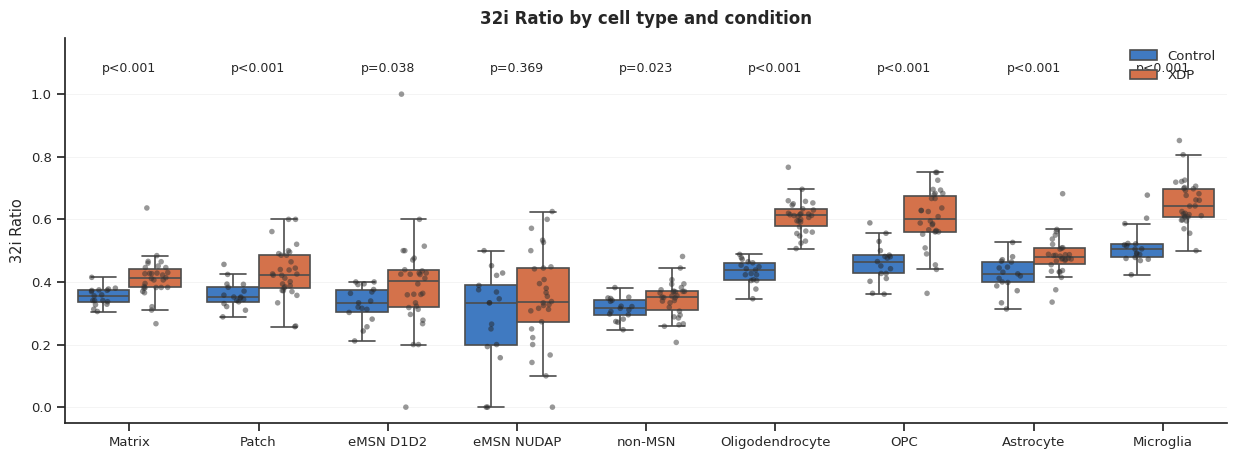

In [31]:
from scipy.stats import mannwhitneyu

CONDITION_COLORS = {"Control": "#2a78d6", "XDP": "#eb6834"}  # blue / orange, same as earlier panels


def annotate_pvals(ax, data, x, y, hue, order, g1="Control", g2="XDP"):
    y_max, y_min = data[y].max(), data[y].min()
    offset = (y_max - y_min) * 0.06 if y_max != y_min else 0.05
    for i, cat in enumerate(order):
        a = data.loc[(data[x] == cat) & (data[hue] == g1), y].dropna()
        b = data.loc[(data[x] == cat) & (data[hue] == g2), y].dropna()
        if len(a) < 2 or len(b) < 2:
            continue
        _, pval = mannwhitneyu(a, b, alternative="two-sided")
        label = f"p={pval:.3f}" if pval >= 0.001 else "p<0.001"
        ax.text(i, y_max + offset, label, ha="center", va="bottom", fontsize=9)
    ax.set_ylim(top=y_max + offset * 3)


def plot_pileup(data, y, order, cell_types, ylabel="32i Ratio"):
    sns.set_theme(style="ticks", context="notebook")
    fig, ax = plt.subplots(figsize=(15, 5))

    sns.boxplot(data=data, x="ct_for_deg", y=y, hue="condition", order=order,
                palette=CONDITION_COLORS, hue_order=["Control", "XDP"],
                showfliers=False, linewidth=1.2, ax=ax)
    sns.stripplot(data=data, x="ct_for_deg", y=y, hue="condition", order=order,
                  hue_order=["Control", "XDP"], dodge=True, color="0.2",
                  size=4, alpha=0.5, jitter=0.2, legend=False, ax=ax)

    annotate_pvals(ax, data, "ct_for_deg", y, "condition", cell_types)

    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=10.5)
    ax.set_xticklabels([lbl.get_text().replace("_", " ") for lbl in ax.get_xticklabels()])
    ax.tick_params(labelsize=9.5)
    ax.grid(axis="y", linewidth=0.5, alpha=0.3)
    sns.despine(ax=ax)
    ax.legend(title=None, fontsize=9.5, frameon=False, loc="upper right")

    ax.set_title(f"{ylabel} by cell type and condition", fontsize=12, fontweight="semibold", pad=10)
    plt.show()


plot_pileup(df_pseudobulk_all, "pileup_metric", cell_types, cell_types, ylabel="32i Ratio")
# plot_pileup(df_pseudobulk_all, "pileup_metric_norm", cell_types, cell_types, ylabel="32i Ratio (normalized)")


# Corr ratio

In [124]:
df_meta = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/original_data/XDP dataset metadata - Gabri's Version.csv")
df_meta.head(2)

,donor_id,original_donor_id,Sex,Condition,Cohort,RQS,DV200,MQS_numerical,MQS,pH,Brain_bank,Year_collected,repeat_length,repeat_length_notes,Age_of_Onset,Age_of_Death,Disease_duration,CAP,immediate_cause_of_death,from_where_this_info_comes_from
0,SCF-22-054,SCF-22-054CM,M,Control,C_1,6.88,0.79,5.0,A,6.0,SCF,2022,0,NaN,not_applicable,51,not_applicable,0.0,Acute Myocardial Infarction,https://docs.google.com/spreadsheets/d/1aY_flq...
1,SCF-23-075,SCF_23_075CM,M,Control,C_2,6.84,0.80,5.0,A,NaN,SCF,2023,0,NaN,not_applicable,60,not_applicable,0.0,Uremia,https://docs.google.com/spreadsheets/d/1aY_flq...


In [134]:
df_pseudobulk_all


covariate_per_cell_type = ["Age_of_Death", "Age_of_Onset", "repeat_length", "Disease_duration"]
XDP_ONLY_COVARIATES = {"repeat_length", "Disease_duration", "Age_of_Onset"}

df_cov = df_pseudobulk_all.merge(df_meta[["donor_id", *covariate_per_cell_type]], on="donor_id", how="left")

df_cov["Age_of_Onset"] = pd.to_numeric(df_cov["Age_of_Onset"], errors="coerce")
df_cov["Disease_duration"] = pd.to_numeric(df_cov["Disease_duration"], errors="coerce")
df_cov["Disease_duration"] = pd.to_numeric(df_cov["Disease_duration"], errors="coerce")


df_cov

,donor_id,n_pre_umis,n_post_umis,condition,pileup_metric,pre_density,post_density,pileup_metric_norm,ct_for_deg,ct,Age_of_Death,Age_of_Onset,repeat_length,Disease_duration
0,PCMC-16-011,46.0,53.0,XDP,0.464646,0.003014,0.004478,0.402316,Matrix,Neuron,55,53.0,35,2.0
1,PCMC-16-012,26.0,55.0,XDP,0.320988,0.001704,0.004647,0.268271,Matrix,Neuron,41,34.0,41,7.0
2,SCF-18-003,109.0,176.0,XDP,0.382456,0.007143,0.014871,0.324469,Matrix,Neuron,41,32.0,42,9.0
3,SCF-18-004,32.0,51.0,XDP,0.385542,0.002097,0.004309,0.327335,Matrix,Neuron,56,41.0,41,15.0
4,SCF-18-006,116.0,258.0,XDP,0.310160,0.007602,0.021800,0.258545,Matrix,Neuron,51,46.0,35,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,SCF-23-075,57.0,63.0,Control,0.475000,0.003735,0.005323,0.412350,Microglia,Glia,60,NaN,0,NaN
419,SCF-23-079,91.0,95.0,Control,0.489247,0.005963,0.008027,0.426244,Microglia,Glia,47,NaN,0,NaN
420,SCF-23-080,58.0,25.0,XDP,0.698795,0.003801,0.002112,0.642767,Microglia,Glia,36,29.0,49,7.0
421,SCF-23-081,11.0,15.0,Control,0.423077,0.000721,0.001267,0.362546,Microglia,Glia,33,NaN,0,NaN



Analyzing covariate: Age_of_Death


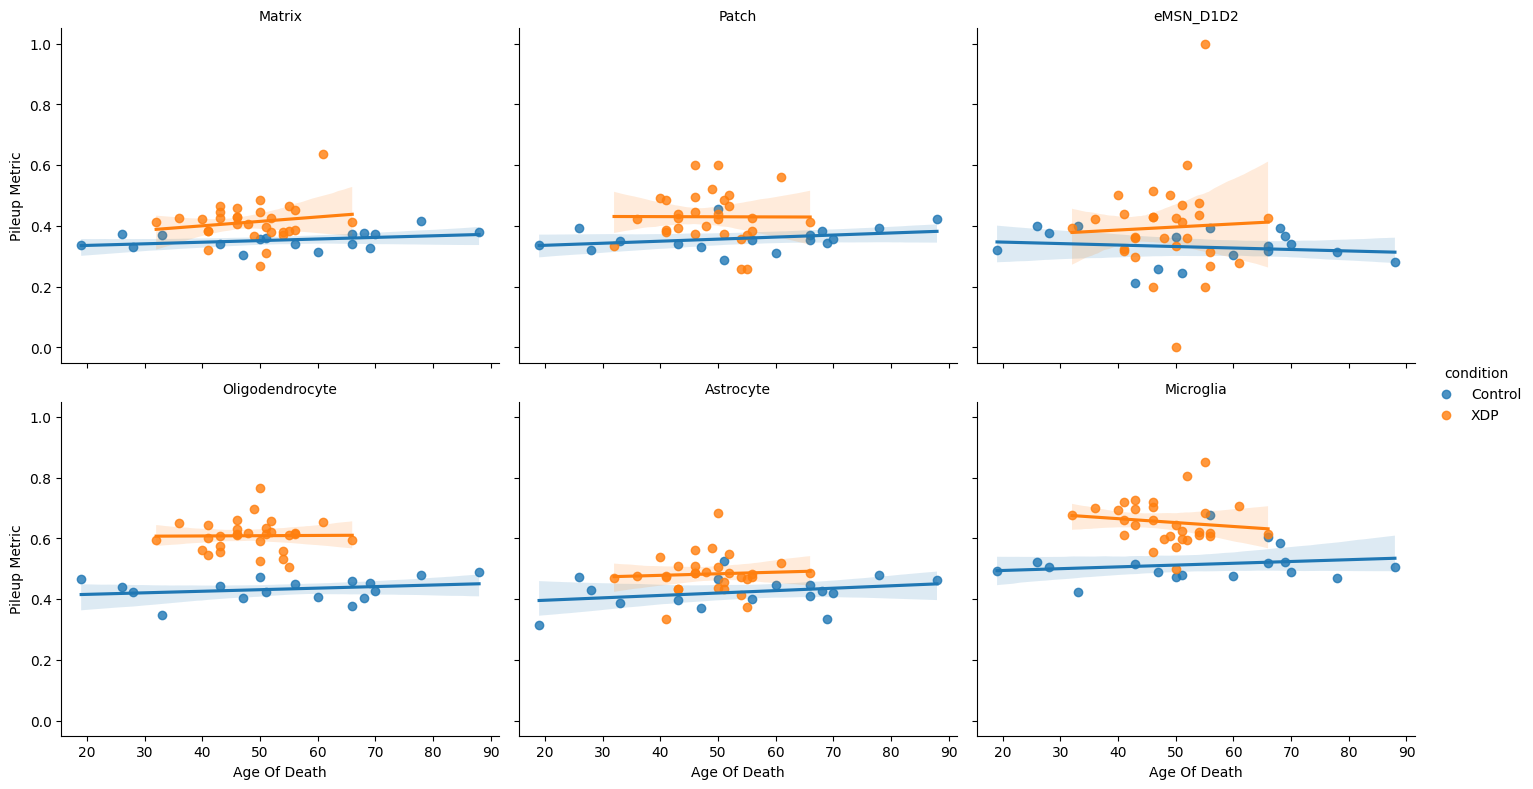

Pearson Correlation: Age_of_Death vs. Pileup Metric
-------------------------------------------------------
Matrix               | Control    | Slope =  0.001 | r =  0.366 | p = 1.482e-01
Matrix               | XDP        | Slope =  0.001 | r =  0.167 | p = 3.779e-01
Patch                | Control    | Slope =  0.001 | r =  0.317 | p = 2.150e-01
Patch                | XDP        | Slope = -0.000 | r = -0.004 | p = 9.814e-01
eMSN_D1D2            | Control    | Slope = -0.000 | r = -0.165 | p = 5.278e-01
eMSN_D1D2            | XDP        | Slope =  0.001 | r =  0.045 | p = 8.124e-01
Oligodendrocyte      | Control    | Slope =  0.001 | r =  0.267 | p = 2.999e-01
Oligodendrocyte      | XDP        | Slope =  0.000 | r =  0.012 | p = 9.510e-01
Astrocyte            | Control    | Slope =  0.001 | r =  0.287 | p = 2.632e-01
Astrocyte            | XDP        | Slope =  0.001 | r =  0.061 | p = 7.486e-01
Microglia            | Control    | Slope =  0.001 | r =  0.193 | p = 4.578e-01
Microglia   

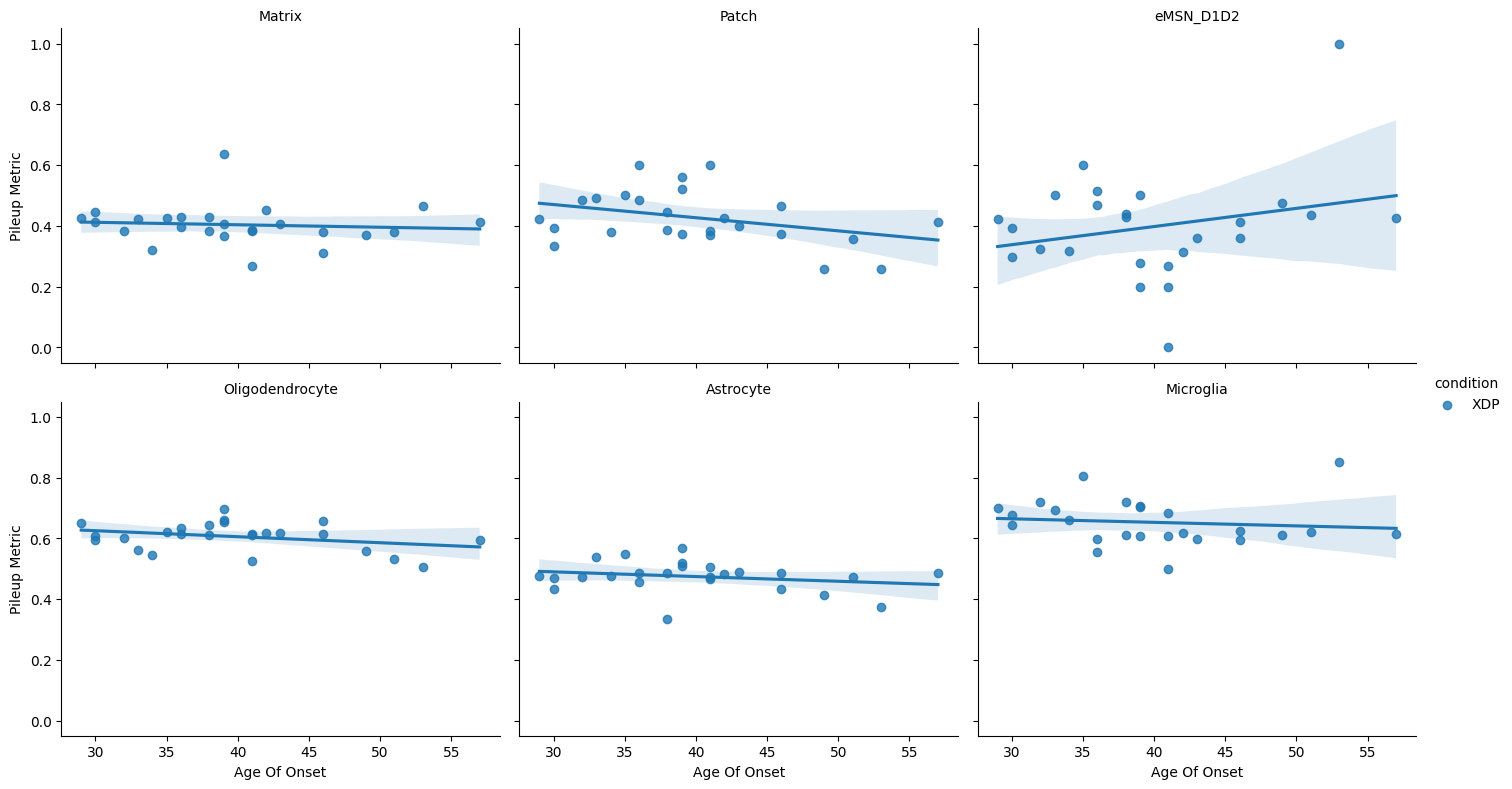

Pearson Correlation: Age_of_Onset vs. Pileup Metric
-------------------------------------------------------
Matrix               | XDP        | Slope = -0.001 | r = -0.090 | p = 6.686e-01
Patch                | XDP        | Slope = -0.004 | r = -0.355 | p = 8.204e-02
eMSN_D1D2            | XDP        | Slope =  0.006 | r =  0.247 | p = 2.342e-01
Oligodendrocyte      | XDP        | Slope = -0.002 | r = -0.315 | p = 1.254e-01
Astrocyte            | XDP        | Slope = -0.002 | r = -0.227 | p = 2.750e-01
Microglia            | XDP        | Slope = -0.001 | r = -0.113 | p = 5.908e-01

Analyzing covariate: repeat_length


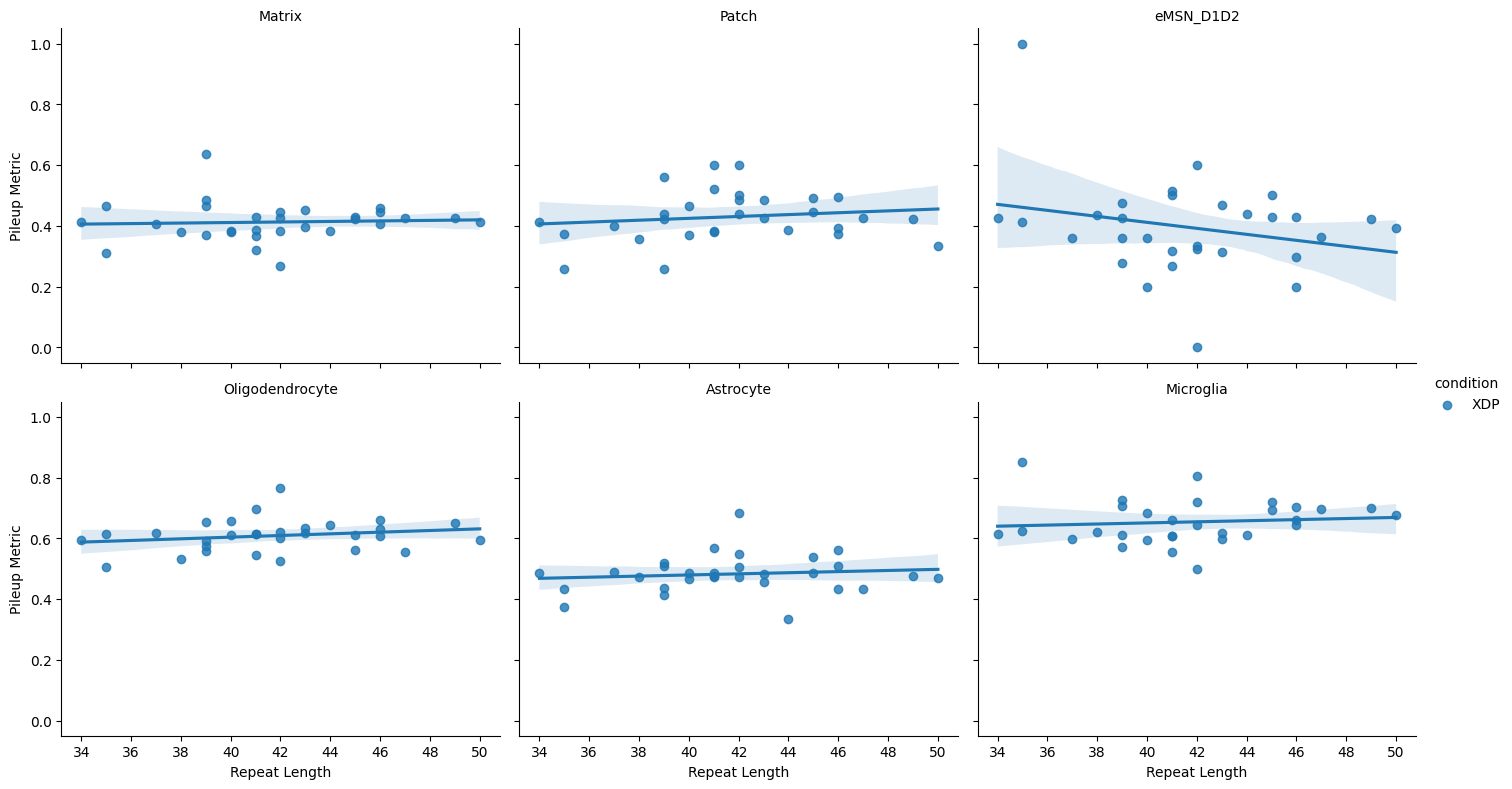

Pearson Correlation: repeat_length vs. Pileup Metric
-------------------------------------------------------
Matrix               | XDP        | Slope =  0.001 | r =  0.055 | p = 7.737e-01
Patch                | XDP        | Slope =  0.003 | r =  0.149 | p = 4.332e-01
eMSN_D1D2            | XDP        | Slope = -0.010 | r = -0.242 | p = 1.979e-01
Oligodendrocyte      | XDP        | Slope =  0.003 | r =  0.206 | p = 2.752e-01
Astrocyte            | XDP        | Slope =  0.002 | r =  0.118 | p = 5.351e-01
Microglia            | XDP        | Slope =  0.002 | r =  0.099 | p = 6.020e-01

Analyzing covariate: Disease_duration


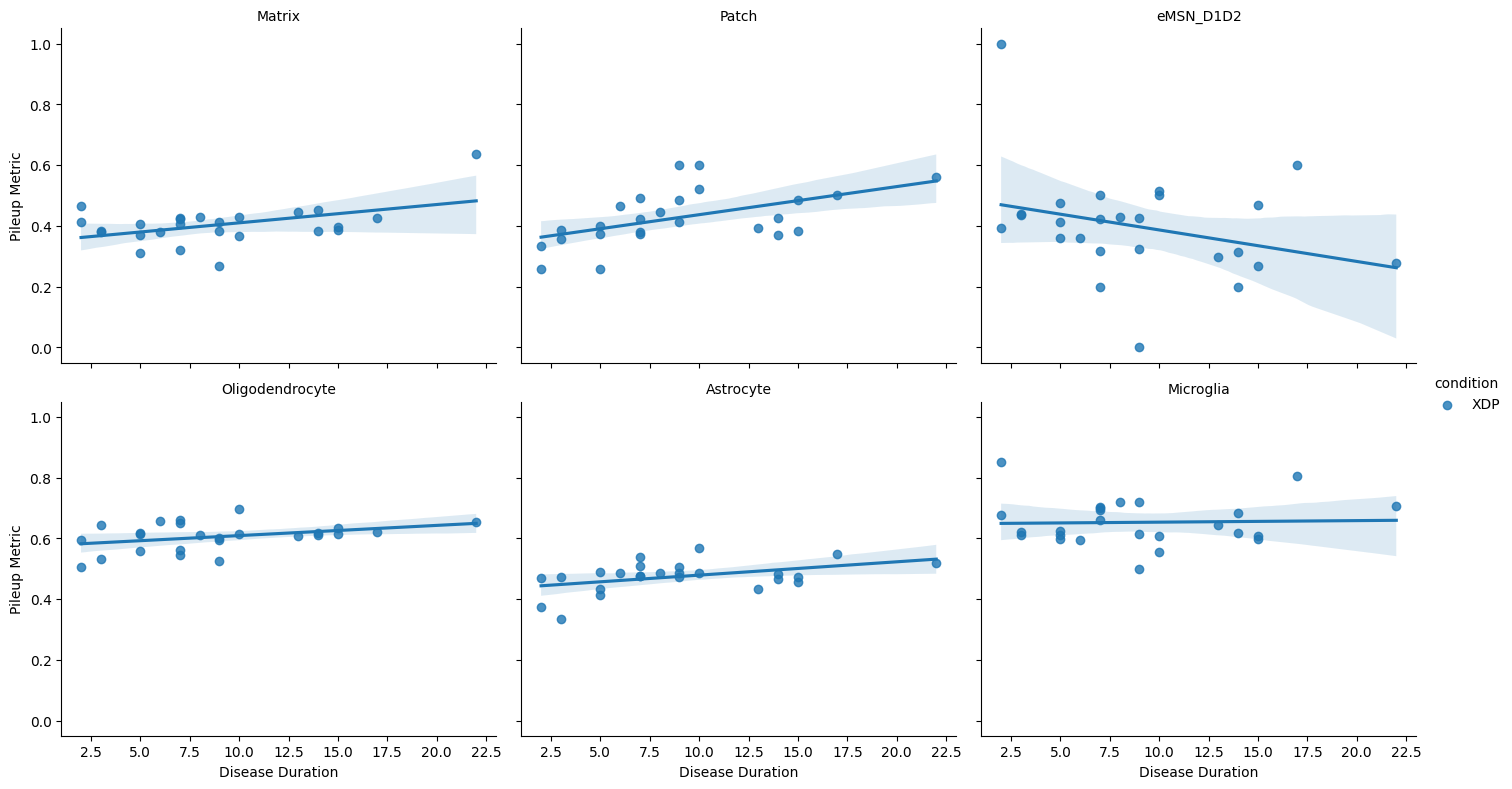

Pearson Correlation: Disease_duration vs. Pileup Metric
-------------------------------------------------------
Matrix               | XDP        | Slope =  0.006 | r =  0.464 | p = 1.961e-02
Patch                | XDP        | Slope =  0.009 | r =  0.525 | p = 7.081e-03
eMSN_D1D2            | XDP        | Slope = -0.010 | r = -0.296 | p = 1.503e-01
Oligodendrocyte      | XDP        | Slope =  0.003 | r =  0.370 | p = 6.874e-02
Astrocyte            | XDP        | Slope =  0.004 | r =  0.445 | p = 2.565e-02
Microglia            | XDP        | Slope =  0.001 | r =  0.034 | p = 8.716e-01


In [138]:
# Plot and calculate corr of metric per cell type: AGE OF DEATH

plot_cell_types = [ct for ct in cell_types if ct != "non-MSN"]  # drop non-MSN so grid is a clean 3x2

for COV in covariate_per_cell_type:

    print(f"\nAnalyzing covariate: {COV}\n{'=' * 60}")

    # 1. GENERATE THE PLOT GRID
    tmp_df = df_cov[df_cov["ct_for_deg"].isin(plot_cell_types)]

    if COV in XDP_ONLY_COVARIATES:
        tmp_df = tmp_df[tmp_df["condition"] == "XDP"]
        tmp_df["condition"] =  tmp_df["condition"].cat.remove_categories("Control")  # drop control from the plot if not present

    n_cols = 3

    g = sns.lmplot(
        data=tmp_df,
        x=COV,
        y="pileup_metric",
        hue="condition",
        col="ct_for_deg",
        col_order=plot_cell_types,   # keep plot order consistent (isin() doesn't preserve it)
        col_wrap=n_cols,
        height=4,
        aspect=1.2,
    )

    g.set_titles("{col_name}")
    g.set_axis_labels(COV.replace("_", " ").title(), "Pileup Metric")
    plt.show()

    # 2. CALCULATE CORRELATIONS
    print(f"Pearson Correlation: {COV} vs. Pileup Metric")
    print("-" * 55)

    for ct in plot_cell_types:
        for condition in ["Control", "XDP"]:
            if condition == "Control" and COV in XDP_ONLY_COVARIATES:
                continue
            tmp = df_cov[(df_cov["ct_for_deg"] == ct) & (df_cov["condition"] == condition)].dropna(subset=[COV, "pileup_metric"])
            if len(tmp) < 2 or tmp[COV].nunique() < 2:
                print(f"{ct:<20} | {condition:<10} | skipped (n={len(tmp)}, unique={tmp[COV].nunique()})")
                continue
            res = linregress(tmp[COV], tmp["pileup_metric"])
            print(f"{ct:<20} | {condition:<10} | Slope = {res.slope:>6.3f} | r = {res.rvalue:>6.3f} | p = {res.pvalue:.3e}")




Analyzing covariate: Age_of_Death


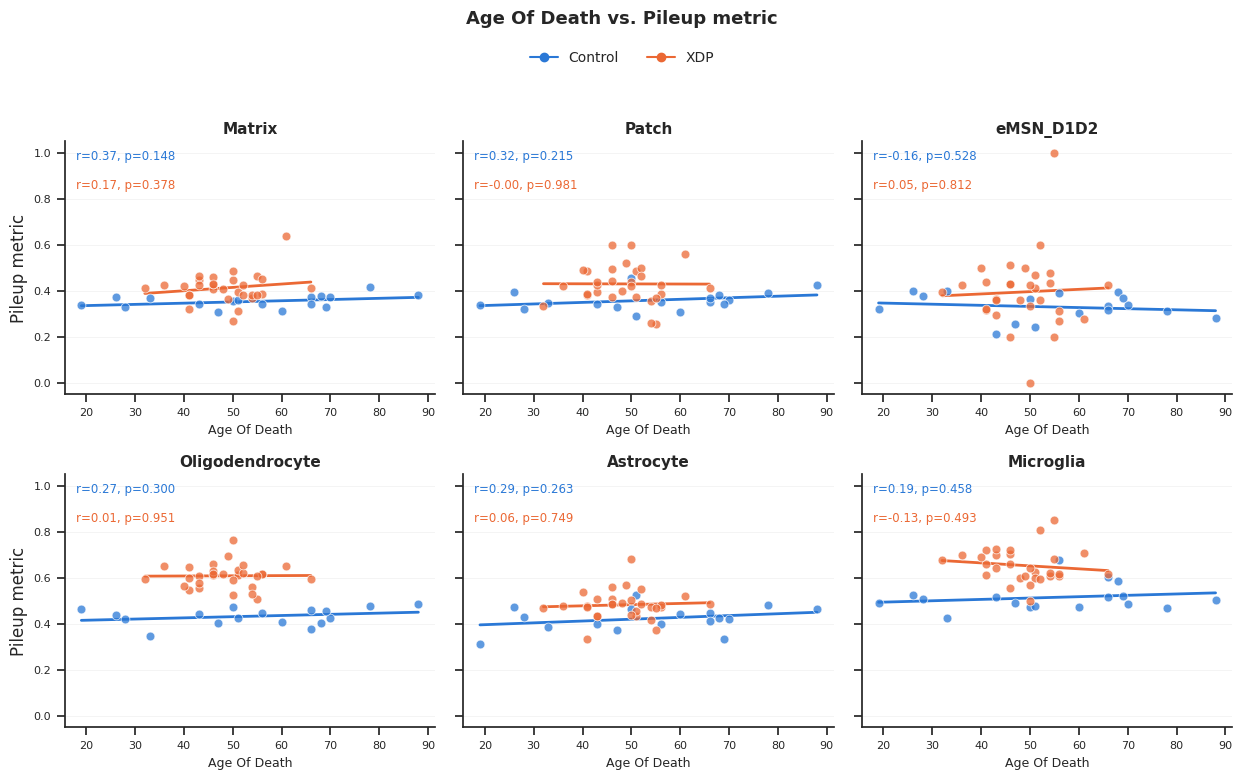

Pearson Correlation: Age_of_Death vs. Pileup Metric
-------------------------------------------------------
Matrix               | Control    | Slope =  0.001 | r =  0.366 | p = 1.482e-01
Matrix               | XDP        | Slope =  0.001 | r =  0.167 | p = 3.779e-01
Patch                | Control    | Slope =  0.001 | r =  0.317 | p = 2.150e-01
Patch                | XDP        | Slope = -0.000 | r = -0.004 | p = 9.814e-01
eMSN_D1D2            | Control    | Slope = -0.000 | r = -0.165 | p = 5.278e-01
eMSN_D1D2            | XDP        | Slope =  0.001 | r =  0.045 | p = 8.124e-01
Oligodendrocyte      | Control    | Slope =  0.001 | r =  0.267 | p = 2.999e-01
Oligodendrocyte      | XDP        | Slope =  0.000 | r =  0.012 | p = 9.510e-01
Astrocyte            | Control    | Slope =  0.001 | r =  0.287 | p = 2.632e-01
Astrocyte            | XDP        | Slope =  0.001 | r =  0.061 | p = 7.486e-01
Microglia            | Control    | Slope =  0.001 | r =  0.193 | p = 4.578e-01
Microglia   

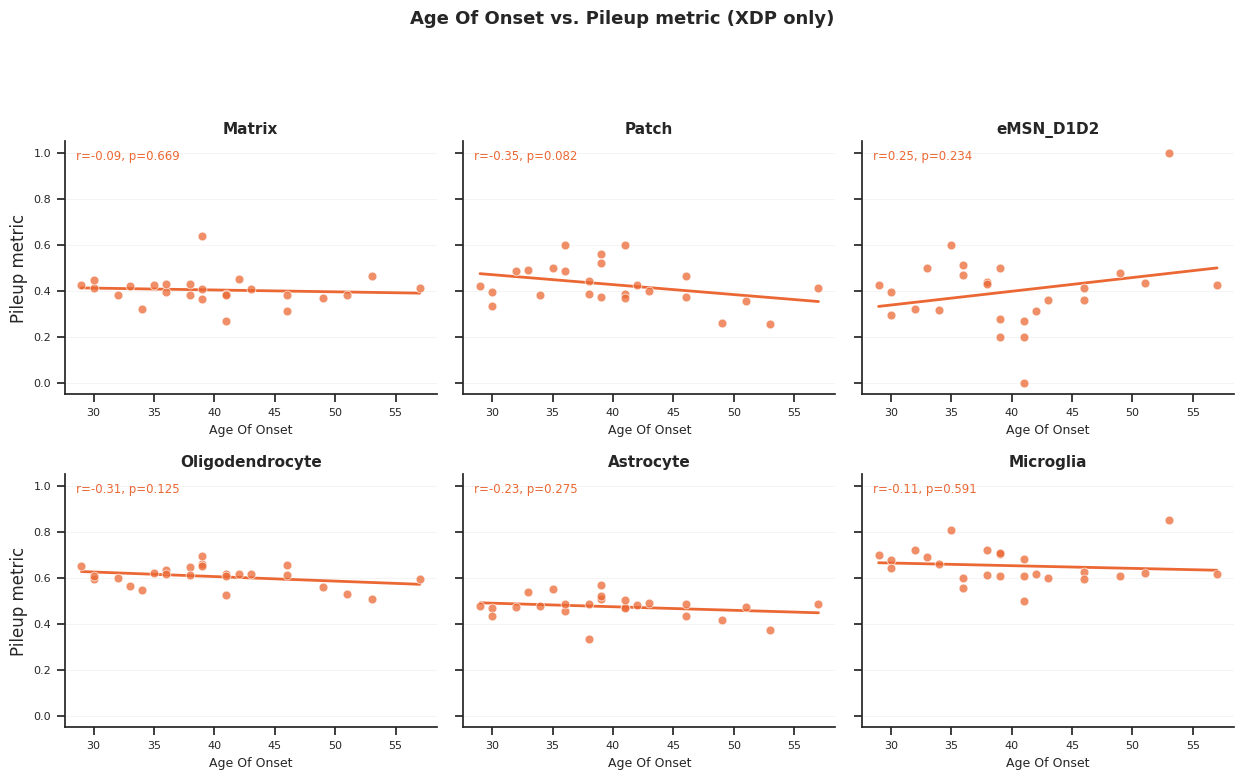

Pearson Correlation: Age_of_Onset vs. Pileup Metric
-------------------------------------------------------
Matrix               | XDP        | Slope = -0.001 | r = -0.090 | p = 6.686e-01
Patch                | XDP        | Slope = -0.004 | r = -0.355 | p = 8.204e-02
eMSN_D1D2            | XDP        | Slope =  0.006 | r =  0.247 | p = 2.342e-01
Oligodendrocyte      | XDP        | Slope = -0.002 | r = -0.315 | p = 1.254e-01
Astrocyte            | XDP        | Slope = -0.002 | r = -0.227 | p = 2.750e-01
Microglia            | XDP        | Slope = -0.001 | r = -0.113 | p = 5.908e-01

Analyzing covariate: repeat_length


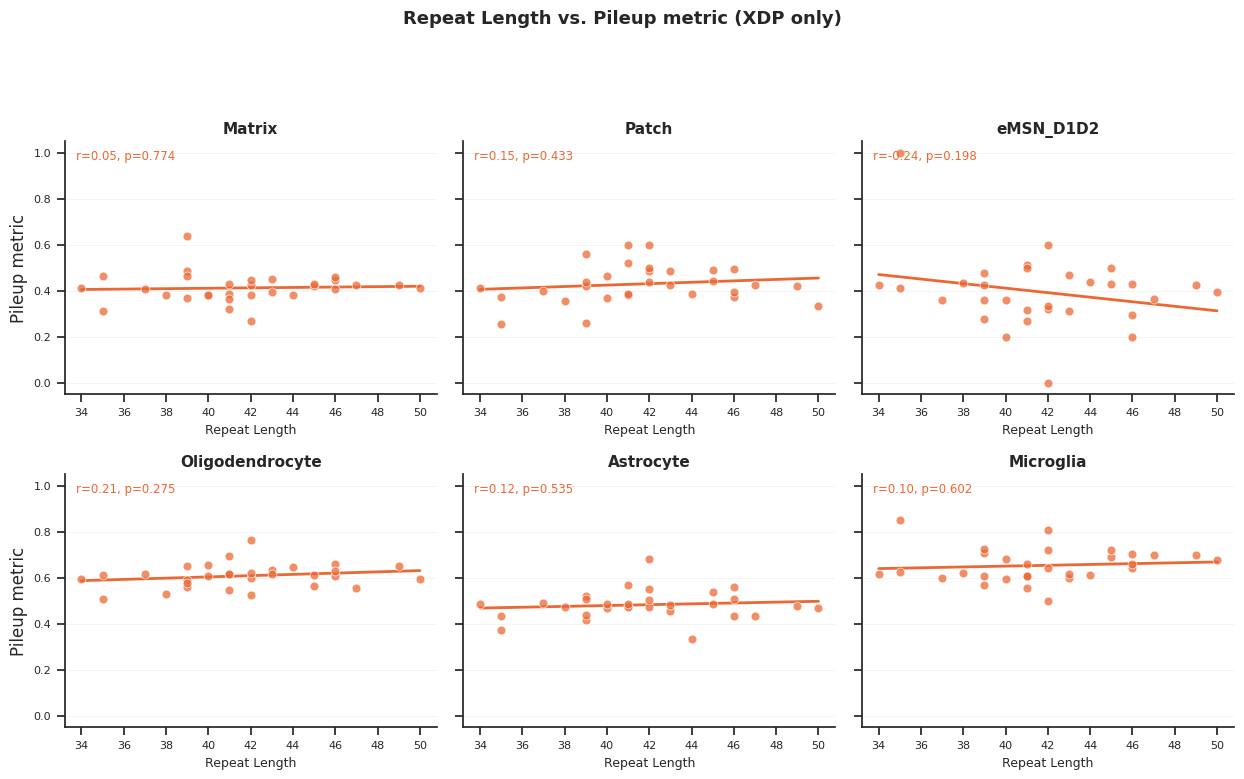

Pearson Correlation: repeat_length vs. Pileup Metric
-------------------------------------------------------
Matrix               | XDP        | Slope =  0.001 | r =  0.055 | p = 7.737e-01
Patch                | XDP        | Slope =  0.003 | r =  0.149 | p = 4.332e-01
eMSN_D1D2            | XDP        | Slope = -0.010 | r = -0.242 | p = 1.979e-01
Oligodendrocyte      | XDP        | Slope =  0.003 | r =  0.206 | p = 2.752e-01
Astrocyte            | XDP        | Slope =  0.002 | r =  0.118 | p = 5.351e-01
Microglia            | XDP        | Slope =  0.002 | r =  0.099 | p = 6.020e-01

Analyzing covariate: Disease_duration


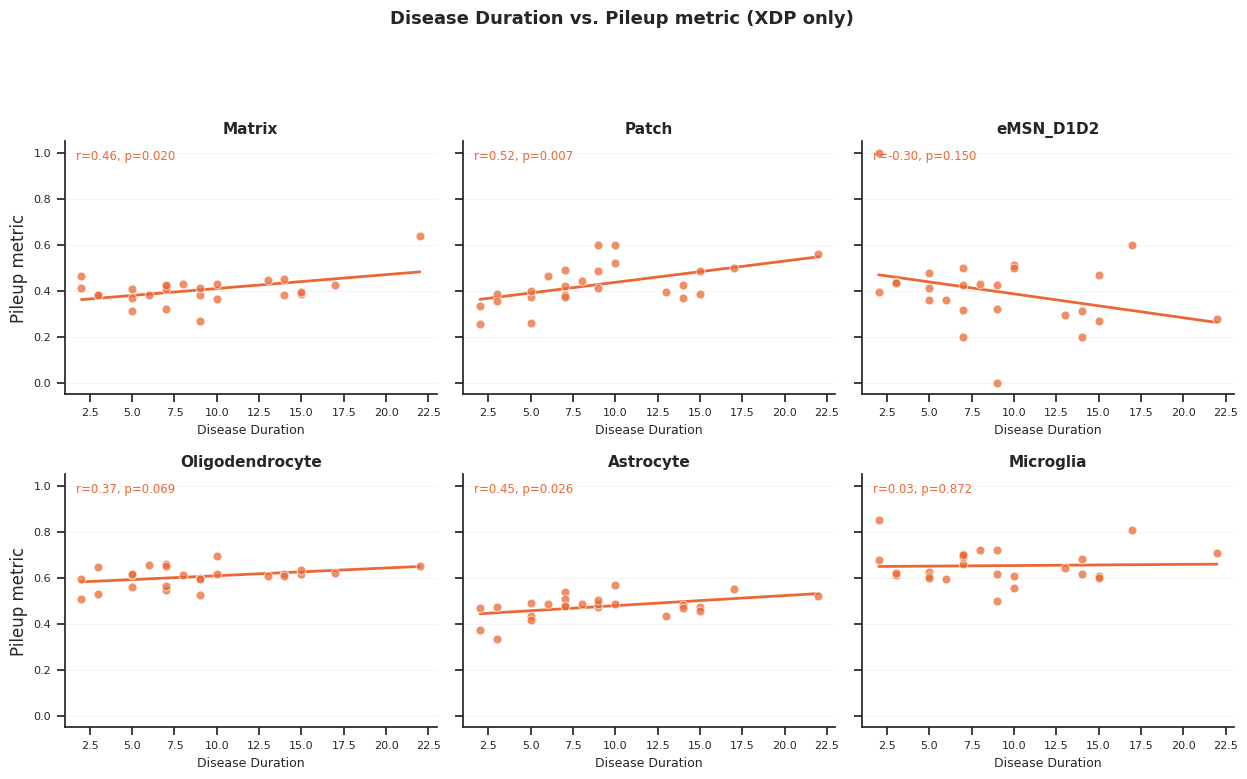

Pearson Correlation: Disease_duration vs. Pileup Metric
-------------------------------------------------------
Matrix               | XDP        | Slope =  0.006 | r =  0.464 | p = 1.961e-02
Patch                | XDP        | Slope =  0.009 | r =  0.525 | p = 7.081e-03
eMSN_D1D2            | XDP        | Slope = -0.010 | r = -0.296 | p = 1.503e-01
Oligodendrocyte      | XDP        | Slope =  0.003 | r =  0.370 | p = 6.874e-02
Astrocyte            | XDP        | Slope =  0.004 | r =  0.445 | p = 2.565e-02
Microglia            | XDP        | Slope =  0.001 | r =  0.034 | p = 8.716e-01


In [139]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# validated colorblind-safe categorical pair — fixed assignment, never cycled
CONDITION_COLORS = {"Control": "#2a78d6", "XDP": "#eb6834"}  # blue / orange

plot_cell_types = [ct for ct in cell_types if ct != "non-MSN"]  # drop non-MSN so grid is a clean 3x2
n_cols = 3
n_rows = -(-len(plot_cell_types) // n_cols)  # ceil division

sns.set_theme(style="ticks", context="notebook")


def fit_and_annotate(ax, x, y, color, label_y):
    """Scatter + regression line + r/p annotation for one condition on ax."""
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]

    ax.scatter(x, y, s=40, color=color, alpha=0.75, edgecolor="white", linewidth=0.6, zorder=3)

    if len(x) < 2 or len(np.unique(x)) < 2:
        ax.text(0.03, label_y, "insufficient data", transform=ax.transAxes,
                 fontsize=8.5, color=color, va="top", style="italic")
        return None

    res = linregress(x, y)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, res.intercept + res.slope * xs, color=color, linewidth=2, zorder=2)

    p_label = "p<0.001" if res.pvalue < 0.001 else f"p={res.pvalue:.3f}"
    ax.text(0.03, label_y, f"r={res.rvalue:.2f}, {p_label}", transform=ax.transAxes,
             fontsize=8.5, color=color, va="top", fontweight="medium")
    return res


for COV in covariate_per_cell_type:

    print(f"\nAnalyzing covariate: {COV}\n{'=' * 60}")

    conditions = ["XDP"] if COV in XDP_ONLY_COVARIATES else ["Control", "XDP"]
    tmp_df = df_cov[df_cov["ct_for_deg"].isin(plot_cell_types)].copy()
    if COV in XDP_ONLY_COVARIATES:
        tmp_df = tmp_df[tmp_df["condition"] == "XDP"]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.6 * n_rows), sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for i, ct in enumerate(plot_cell_types):
        ax = axes[i]
        sub = tmp_df[tmp_df["ct_for_deg"] == ct]

        label_y = 0.97
        for cond in conditions:
            s = sub[sub["condition"] == cond].dropna(subset=[COV, "pileup_metric"])
            fit_and_annotate(ax, s[COV], s["pileup_metric"], CONDITION_COLORS[cond], label_y)
            label_y -= 0.115

        ax.set_title(ct, fontsize=11, fontweight="semibold", pad=6)
        ax.set_xlabel(COV.replace("_", " ").title(), fontsize=9)
        ax.set_ylabel("Pileup metric" if i % n_cols == 0 else "")
        ax.tick_params(labelsize=8)
        ax.grid(axis="y", linewidth=0.5, alpha=0.3)
        sns.despine(ax=ax)

    for j in range(len(plot_cell_types), len(axes)):
        axes[j].set_visible(False)

    if len(conditions) > 1:
        handles = [plt.Line2D([0], [0], marker="o", linestyle="-", color=CONDITION_COLORS[c],
                                label=c, markersize=6) for c in conditions]
        fig.legend(handles=handles, loc="upper center", ncol=len(conditions),
                    bbox_to_anchor=(0.5, 1.04), frameon=False, fontsize=10)

    title_suffix = " (XDP only)" if len(conditions) == 1 else ""
    fig.suptitle(f"{COV.replace('_', ' ').title()} vs. Pileup metric{title_suffix}",
                  y=1.08, fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()

    # printed summary (same stats as annotated on the plot, for scanning many at once)
    print(f"Pearson Correlation: {COV} vs. Pileup Metric")
    print("-" * 55)
    for ct in plot_cell_types:
        for condition in conditions:
            tmp = df_cov[(df_cov["ct_for_deg"] == ct) & (df_cov["condition"] == condition)].dropna(subset=[COV, "pileup_metric"])
            if len(tmp) < 2 or tmp[COV].nunique() < 2:
                print(f"{ct:<20} | {condition:<10} | skipped (n={len(tmp)}, unique={tmp[COV].nunique()})")
                continue
            res = linregress(tmp[COV], tmp["pileup_metric"])
            print(f"{ct:<20} | {condition:<10} | Slope = {res.slope:>6.3f} | r = {res.rvalue:>6.3f} | p = {res.pvalue:.3e}")


# Ratio corr taf1 expression

In [41]:
# checj if taf1 expression correlates with the pileup metric (it should, if the metric is meaningful)

taf1_index = nucseq.var[nucseq.var["gene_symbol"] == "TAF1"].index.values[0]
taf1_col = nucseq[obs_nuc.index, taf1_index].to_memory().X
obs_nuc["taf1_total_umis"] = np.asarray(taf1_col.todense()).flatten() if hasattr(taf1_col, "todense") else np.asarray(taf1_col).flatten()
display(obs_nuc[["donor_id", "ct_for_deg", "taf1_total_umis"]].head())

donor_taf1 = obs_nuc.groupby(["donor_id", "ct_for_deg"])["taf1_total_umis"].mean().reset_index()
df_taf1 = df_pseudobulk_all.merge(donor_taf1, on=["donor_id", "ct_for_deg"], how="left")
display(df_taf1[["donor_id", "ct_for_deg", "taf1_total_umis", "pileup_metric_norm"]].head())

from scipy.stats import spearmanr
for ct in cell_types:
    sub = df_taf1.loc[df_taf1["ct_for_deg"] == ct, ["taf1_total_umis", "pileup_metric_norm", "condition", "donor_id"]].dropna()
    rho, pval = spearmanr(sub["taf1_total_umis"], sub["pileup_metric_norm"])
    sns.scatterplot(data=sub, x="taf1_total_umis", y="pileup_metric_norm", hue="condition"); plt.title(f"{ct} - Spearman rho={rho:.2f}, p={pval:.3f}"); plt.show()
    print(f"{ct}: n={len(sub)}, rho={rho:.2f}, p={pval:.3f}")

    display(obs_nuc[
        (obs_nuc["donor_id"].isin(sub.loc[sub["taf1_total_umis"] < 0.5, "donor_id"])) &
        (obs_nuc["ct_for_deg"] == ct)
        ])


AttributeError: 'RangeIndex' object has no attribute 'reshape'

# IGNORE DOWNSTREAM 
---

# Slidetag

# Read adata with filtered cell
Used to knwo whcih ar egood cell barcodes

In [ ]:
import scanpy as sc

adata = sc.read_h5ad(
    "/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/all_lib_adata.h5ad",
    backed="r",
)
# adata_s = adata[
#     (adata.obs["sample"] == "sample_02") &
#     (adata.obs["library"] == "SI-TT-C1")
#     ].to_memory().copy()
# adata_s

# Load librarie info

In [ ]:
# Load libraries info
df_libraries = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/SlideTags_XDP_metadata/XDP Slidetags - CellBender Terra table - cb.csv")
df_libraries

df_sample_meta = df_libraries.drop_duplicates(subset=["donor_number"])[["donor_number", "sex", "condition"]]
df_sample_meta

,donor_number,sex,condition
0,sample_01,male,diseased
3,sample_02,male,diseased
7,sample_03,male,diseased
11,sample_04,male,diseased
15,sample_05,male,healthy
18,sample_06,male,diseased
21,sample_07,male,healthy
24,sample_08,male,diseased
29,sample_09,male,diseased


In [ ]:
# df_libraries = df_libraries[df_libraries["entity:library_id"] == "260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C1"]
df_libraries = df_libraries[df_libraries["donor_number"] == "sample_02"]

df_libraries

,entity:library_id,donor_number,donor_id,condition,sex,age_at_onset,age_at_death,bcl,RNAindex,SBindex,...,cellranger_count_h5,terra_slidetag,terra_cellbender,terra_dropsift,script_01_adata,script_02_mmc,script_03_QC,script_04_merge,script_05_zone (4 / 6),script_06_ct_for_deg
3,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B10,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B10,SI-TT-A11,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN
4,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B11,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B11,SI-TT-A12,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN
5,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B12,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B12,SI-TT-B1,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN
6,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C1,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C1,SI-TT-B2,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN


# Per sample + Reads based --> Retention intron metric
download bam subset to taf1 

count how many read splan ex32(33)

same method of https://pmc.ncbi.nlm.nih.gov/articles/PMC11331120/#s10

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd

# ---------------------------------------------------------------------------
# Coordinates (unchanged from your cell)
# ---------------------------------------------------------------------------
TAF1_START_END_W = "71366000-71467000"
TAF1_EXON32_START_END = "71424154-71424238"
TAF1_INTRON32_START_END = "71424239-71454169"
TAF1_EXON33_START_END = "71454170-71454237"

EXON32_LAST_BP    = TAF1_EXON32_START_END.split("-")[1]
INTRON32_FIRST_BP = TAF1_INTRON32_START_END.split("-")[0]
INTRON32_LAST_BP  = TAF1_INTRON32_START_END.split("-")[1]
INTRON_LENGHT     = int(INTRON32_LAST_BP) - int(EXON32_LAST_BP)  # 29931

TAF1_EXON32_INTRON32_JUNCTION_W = f"{int(EXON32_LAST_BP)-9}-{int(INTRON32_FIRST_BP)+9}"

results = []

for _, row in df_libraries.iterrows():

    lib, bcl, sample = row["RNAindex"], row["bcl"], row["donor_number"]

    # Save barcodes that are good cells
    adata_s = adata[(adata.obs["sample"] == sample) & (adata.obs["library"] == lib)].obs.copy()
    CALLED_CELLS = set(adata_s["original_barcode"])
    TMP_BC_FILE = Path("/home/gdallagl/myworkdir/XDP/data/_old/called_cells.txt")
    with open(TMP_BC_FILE, "w") as f:
        for cell in CALLED_CELLS:
            f.write(f"{cell}\n")

    save_folder = f"$HOME/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/{sample}/{bcl}/{lib}/bam"
    bam = f"gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/gene-expression/{bcl}/{lib}/outs/possorted_genome_bam.bam"

    script = f"""
                set -e
                
                # allow igv tools to be used
                export JAVA_HOME=$HOME/myworkdir/tools/IGV_Linux_2.19.8/jdk-21
                export PATH="$JAVA_HOME/bin:$HOME/myworkdir/tools/IGV_2.19.8:$PATH"

                SAVE_FOLDER="{save_folder}"
                mkdir -p "$SAVE_FOLDER"
                cd "$SAVE_FOLDER"

                BAM="{bam}"
                export GCS_OAUTH_TOKEN=$(gcloud auth print-access-token)

                # subset + QC filter + index
                samtools view -b \
                -q 30 -F 0x904 \
                -D CB:"{TMP_BC_FILE}" \
                "$BAM" \
                chrX:{TAF1_START_END_W} \
                -o taf1_subset.bam
                samtools index taf1_subset.bam

                echo "Before filters:"
                samtools view -c "$BAM" chrX:{TAF1_START_END_W}
                echo "After filters:"
                samtools view -c taf1_subset.bam

                # --- denominator + retention: per-base depth via igvtools ---
                # -w 1 --> coutn how many reads overlap each base
                # --query chrX:{EXON32_LAST_BP}-{INTRON32_FIRST_BP} --> only count the bases of interest
                igvtools count -w 1 --query chrX:{EXON32_LAST_BP}-{INTRON32_FIRST_BP} taf1_subset.bam depth.wig hg38

                # --- canonical splice count: exact-length CIGAR match via samtools ---
                # chr:... --> return each read whose SPAN overlaps the junction
                # -6 --> return the CIGAR string for each read (coluimn 6)
                samtools view taf1_subset.bam chrX:{TAF1_EXON32_INTRON32_JUNCTION_W} \
                | cut -f 6 \
                | grep -c "{INTRON_LENGHT}N" || true
            """
    
    # reun sciprt
    proc = subprocess.run(["bash", "-c", script], capture_output=True, text=True)
    if proc.returncode != 0:
        print(f"FAILED: {sample}/{bcl}/{lib}\n{proc.stderr}")
        continue

    # get umebr of spliced reads from samtools
    stdout_lines = proc.stdout.strip().splitlines()
    print(stdout_lines)
    n_spliced = int(stdout_lines[-1])  # last line = grep -c output


    # --- parse depth.wig for the two exact positions ---
    wig_path = f"{save_folder.replace('$HOME', str(Path.home()))}/depth.wig"
    n_exon32_last_bp = n_intron32_first_bp = 0
    for line in open(wig_path):
        if line.startswith(("track", "variableStep", "fixedStep")):
            continue
        pos_str, val_str = line.strip().split()
        pos = int(pos_str)
        if pos == int(EXON32_LAST_BP):
            n_exon32_last_bp = int(float(val_str))
        elif pos == int(INTRON32_FIRST_BP):
            n_intron32_first_bp = int(float(val_str))

    results.append({
        "sample": sample, "bcl": bcl, "library": lib,
        "n_exon32_last_bp": n_exon32_last_bp,
        "n_intron32_first_bp": n_intron32_first_bp,
        "n_spliced_32_33": n_spliced,
        "retention_proportion": n_intron32_first_bp / n_exon32_last_bp if n_exon32_last_bp else float("nan"),
        "splicing_proportion": n_spliced / n_exon32_last_bp if n_exon32_last_bp else float("nan"),
    })

df_metrics = pd.DataFrame(results)
df_metrics

['Before filters:', '80753', 'After filters:', '52126', 'Using system JDK.', 'Done', '72']
['Before filters:', '79238', 'After filters:', '50563', 'Using system JDK.', 'Done', '75']
['Before filters:', '50918', 'After filters:', '38403', 'Using system JDK.', 'Done', '39']
['Before filters:', '72395', 'After filters:', '49752', 'Using system JDK.', 'Done', '78']
['Before filters:', '73053', 'After filters:', '51794', 'Using system JDK.', 'Done', '90']
['Before filters:', '72040', 'After filters:', '51210', 'Using system JDK.', 'Done', '101']
['Before filters:', '64956', 'After filters:', '47909', 'Using system JDK.', 'Done', '40']
['Before filters:', '105622', 'After filters:', '70341', 'Using system JDK.', 'Done', '153']
['Before filters:', '93604', 'After filters:', '65097', 'Using system JDK.', 'Done', '84']
['Before filters:', '114885', 'After filters:', '79781', 'Using system JDK.', 'Done', '217']
['Before filters:', '97773', 'After filters:', '72754', 'Using system JDK.', 'Done', 

,sample,bcl,library,n_exon32_last_bp,n_intron32_first_bp,n_spliced_32_33,retention_proportion,splicing_proportion
0,sample_01,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H1,56,13,72,0.232143,1.285714
1,sample_01,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H2,67,16,75,0.238806,1.119403
2,sample_01,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H3,51,16,39,0.313725,0.764706
3,sample_02,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B10,35,4,78,0.114286,2.228571
4,sample_02,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B11,29,7,90,0.241379,3.103448
5,sample_02,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B12,33,8,101,0.242424,3.060606
6,sample_02,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C1,47,22,40,0.468085,0.851064
7,sample_03,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C2,86,20,153,0.232558,1.779070
8,sample_03,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C3,38,4,84,0.105263,2.210526
9,sample_03,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C4,38,2,217,0.052632,5.710526


In [ ]:
df_metrics_s

,n_exon32_last_bp,n_intron32_first_bp,n_spliced_32_33,retention_proportion,spliced_proportion,donor_number,sex,condition
0,174,45,186,0.258621,1.068966,sample_01,male,diseased
3,144,41,309,0.284722,2.145833,sample_02,male,diseased
7,202,36,520,0.178218,2.574257,sample_03,male,diseased
11,128,37,225,0.289062,1.757812,sample_04,male,diseased
15,110,18,263,0.163636,2.390909,sample_05,male,healthy
18,98,22,269,0.224490,2.744898,sample_06,male,diseased
21,76,14,180,0.184211,2.368421,sample_07,male,healthy
24,297,63,521,0.212121,1.754209,sample_08,male,diseased
29,1018,270,1341,0.265226,1.317289,sample_09,male,diseased


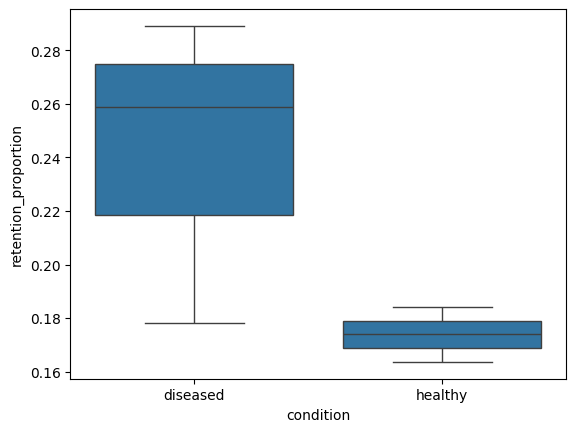

<Axes: xlabel='condition', ylabel='spliced_proportion'>

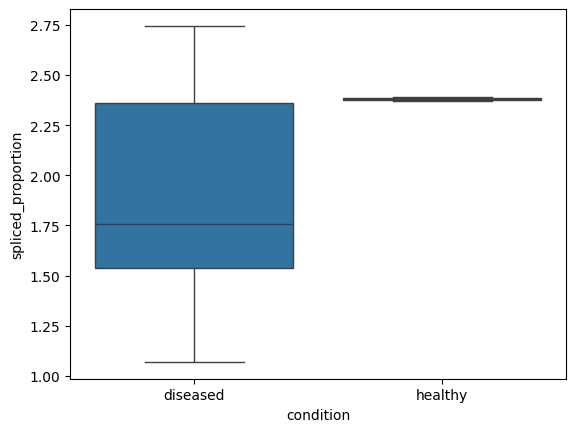

In [ ]:
df_metrics_s = df_metrics.groupby("sample")[["n_exon32_last_bp", "n_intron32_first_bp", "n_spliced_32_33"]].sum()
df_metrics_s["retention_proportion"] = df_metrics_s["n_intron32_first_bp"] / df_metrics_s["n_exon32_last_bp"]
df_metrics_s["spliced_proportion"] = df_metrics_s["n_spliced_32_33"] / df_metrics_s["n_exon32_last_bp"]
df_metrics_s = df_metrics_s.merge(df_sample_meta, left_index=True, right_on="donor_number")

sns.boxplot(
    data=df_metrics_s.reset_index(),
    x="condition",
    y="retention_proportion",
    #hue="condition"
); plt.show()

sns.boxplot(
    data=df_metrics_s.reset_index(),
    x="condition",
    y="spliced_proportion",
    #hue="condition"
); plt.show()

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import pysam

# ---------------------------------------------------------------------------
# Coordinates (GRCh38)
# ---------------------------------------------------------------------------
TAF1_START_END_W = "71366000-71467000"   # wide region to subset the BAM into (covers whole area of interest)

EXON32_LAST_BP    = 71424238   # last bp of exon 32
INTRON32_FIRST_BP = 71424239   # first bp of intron 32 (= start of "pre" / 32i region)
EXON33_START_BP   = 71454170   # first bp of exon 33 (= start of "post" region)
EXON38_END_BP     = 71466005   # last bp of exon 38 (= end of "post" region)
EXON33_END_BP     = 71454237   # last bp of exon 33 (= end of "post" region)
SVA_START_BP      = 71439499   # published start of the SVA insertion (= end of "pre" / 32i region)
71440488

# canonical splice length: exon32 -> exon33, skipping the whole intron
# any read showing exactly this splice length is a NORMAL, fully-spliced transcript,
# not a 32i-like pile-up read -- even if it happens to overlap the "pre" window
CANONICAL_SPLICE_LEN = EXON33_START_BP - EXON32_LAST_BP - 1   # 29931

# "pre" region = 32i intron pile-up: from right after exon 32 up to the SVA insertion
PRE_START = INTRON32_FIRST_BP
PRE_END   = SVA_START_BP

# "post" region = downstream normal transcript: exons 33 through 38, pooled
POST_START = EXON33_START_BP
POST_END   = EXON33_END_BP

results = []

for _, row in df_libraries.iterrows():
    lib, bcl, sample = row["RNAindex"], row["bcl"], row["donor_number"]

    # -----------------------------------------------------------------
    # write this library's QC-passing barcodes to a file for -D CB filtering
    # -----------------------------------------------------------------
    adata_s = adata[(adata.obs["sample"] == sample) & (adata.obs["library"] == lib)].obs.copy()
    CALLED_CELLS = set(adata_s["original_barcode"])
    TMP_BC_FILE = Path("/home/gdallagl/myworkdir/XDP/data/_old/called_cells.txt")
    with open(TMP_BC_FILE, "w") as f:
        for cell in CALLED_CELLS:
            f.write(f"{cell}\n")

    save_folder = f"$HOME/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/{sample}/{bcl}/{lib}/bam"
    bam = f"gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/gene-expression/{bcl}/{lib}/outs/possorted_genome_bam.bam"

    # -----------------------------------------------------------------
    # subset + QC filter + index (same as baseline -- samtools only,
    # since this step just narrows down the BAM, no counting happens here)
    # -----------------------------------------------------------------
    script = f"""
        set -e
        SAVE_FOLDER="{save_folder}"
        mkdir -p "$SAVE_FOLDER"
        cd "$SAVE_FOLDER"

        BAM="{bam}"
        export GCS_OAUTH_TOKEN=$(gcloud auth print-access-token)

        samtools view -b \
          -q 30 -F 0x904 \
          -D CB:"{TMP_BC_FILE}" \
          "$BAM" \
          chrX:{TAF1_START_END_W} \
          -o taf1_subset.bam
        samtools index taf1_subset.bam

        echo "Before filters:"
        samtools view -c "$BAM" chrX:{TAF1_START_END_W}
        echo "After filters:"
        samtools view -c taf1_subset.bam
    """
    proc = subprocess.run(["bash", "-c", script], capture_output=True, text=True)
    if proc.returncode != 0:
        print(f"FAILED (subset step): {sample}/{bcl}/{lib}\n{proc.stderr}")
        continue
    print(proc.stdout)

    subset_bam_path = f"{save_folder.replace('$HOME', str(Path.home()))}/taf1_subset.bam"

    # -----------------------------------------------------------------
    # UMI counting -- this needs pysam, not samtools/igvtools, because
    # we need per-read CB/UMI tags to deduplicate PCR-amplified copies
    # of the same molecule down to one count each.
    # -----------------------------------------------------------------
    bam_fh = pysam.AlignmentFile(subset_bam_path, "rb")

    pre_umis = set()   # unique (CB, UMI) pairs with real coverage in the "pre" (32i) region
    post_umis = set()  # unique (CB, UMI) pairs with real coverage in the "post" (exon33-38) region

    def overlaps_window(read, win_start, win_end):
        """
        True only if the read has a real aligned base physically inside
        [win_start, win_end) -- checked via aligned blocks, not just the
        read's outer reference span. A read that splices straight over this
        window (e.g. exon32 -> exon33) has a huge span but NO aligned base
        inside an intronic window, and must not be counted as "pre" coverage.
        """
        win_start0, win_end0 = win_start - 1, win_end - 1  # convert to 0-based half-open
        for block_start, block_end in read.get_blocks():
            if block_start < win_end0 and block_end > win_start0:
                return True
        return False

    def has_canonical_splice(read):
        """
        True if this read's CIGAR contains a gap of EXACTLY the canonical
        exon32->exon33 intron length. Such a read represents a normal,
        fully-spliced transcript that happened to be returned by fetch()
        because its span crosses the "pre" window -- it must be excluded
        from the 32i pile-up count even if overlaps_window() said yes
        (this can only happen right at the window edges).
        """
        if read.cigartuples is None:
            return False
        return any(op == 3 and length == CANONICAL_SPLICE_LEN for op, length in read.cigartuples)

    # --- scan the "pre" (32i) region ---
    for read in bam_fh.fetch("chrX", PRE_START, PRE_END):
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        if not (read.has_tag("CB") and read.has_tag("UB")):
            continue
        if not overlaps_window(read, PRE_START, PRE_END):
            continue
        if has_canonical_splice(read):
            continue  # this is a normal spliced transcript, not 32i pile-up
        pre_umis.add((read.get_tag("CB"), read.get_tag("UB")))

    # --- scan the "post" (exon33-38) region ---
    for read in bam_fh.fetch("chrX", POST_START, POST_END):
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        if not (read.has_tag("CB") and read.has_tag("UB")):
            continue
        if not overlaps_window(read, POST_START, POST_END):
            continue
        post_umis.add((read.get_tag("CB"), read.get_tag("UB")))

    bam_fh.close()

    n_pre = len(pre_umis)
    n_post = len(post_umis)

    results.append({
        "sample": sample, "bcl": bcl, "library": lib,
        "n_pre_umis": n_pre,
        "n_post_umis": n_post,
        "pileup_metric": n_pre / (n_pre + n_post) if (n_pre + n_post) > 0 else float("nan"),
    })

df_metrics = pd.DataFrame(results)
df_metrics

Before filters:
80753
After filters:
52126

Before filters:
79238
After filters:
50563

Before filters:
50918
After filters:
38403

Before filters:
72395
After filters:
49752

Before filters:
73053
After filters:
51794

Before filters:
72040
After filters:
51210

Before filters:
64956
After filters:
47909

Before filters:
105622
After filters:
70341

Before filters:
93604
After filters:
65097

Before filters:
114885
After filters:
79781

Before filters:
97773
After filters:
72754

Before filters:
84974
After filters:
51467

Before filters:
85935
After filters:
47915

Before filters:
95209
After filters:
44431

Before filters:
74229
After filters:
52839

Before filters:
72582
After filters:
54588

Before filters:
75099
After filters:
56091

Before filters:
73516
After filters:
54803

Before filters:
112010
After filters:
74649

Before filters:
91027
After filters:
60200

Before filters:
99218
After filters:
65792

Before filters:
77361
After filters:
55193

Before filters:
58888
After f

,sample,bcl,library,n_pre_umis,n_post_umis,pileup_metric
0,sample_01,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H1,6643,108,0.984002
1,sample_01,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H2,6359,120,0.981479
2,sample_01,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H3,5033,88,0.982816
3,sample_02,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B10,3137,99,0.969407
4,sample_02,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B11,2318,84,0.965029
5,sample_02,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B12,2149,79,0.964542
6,sample_02,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C1,4249,102,0.976557
7,sample_03,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C2,4576,146,0.969081
8,sample_03,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C3,1618,56,0.966547
9,sample_03,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C4,1148,48,0.959866


,n_pre_umis,n_post_umis,pileup_metric,pre_density,post_density,pileup_metric_norm,donor_number,sex,condition
0,18035,316,0.982780,1.181848,4.716418,0.200372,sample_01,male,diseased
3,11853,364,0.970205,0.776737,5.432836,0.125087,sample_02,male,diseased
7,11563,355,0.970213,0.757733,5.298507,0.125116,sample_03,male,diseased
11,12658,267,0.979342,0.829489,3.985075,0.172287,sample_04,male,diseased
15,6590,322,0.953414,0.431848,4.805970,0.082448,sample_05,male,healthy
18,9866,220,0.978188,0.646527,3.283582,0.164506,sample_06,male,diseased
21,4854,173,0.965586,0.318087,2.582090,0.109678,sample_07,male,healthy
24,29854,632,0.979269,1.956356,9.432836,0.171773,sample_08,male,diseased
29,45442,1570,0.966604,2.977851,23.432836,0.112752,sample_09,male,diseased


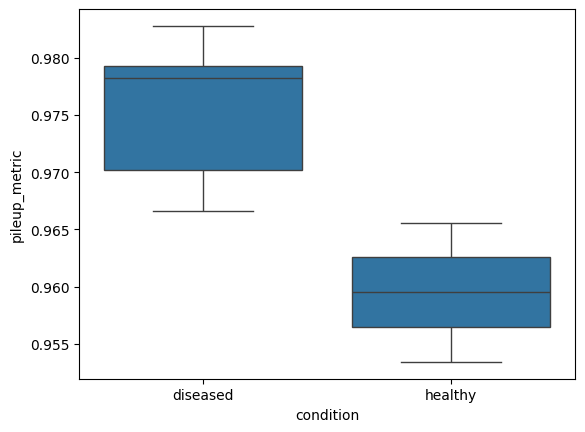

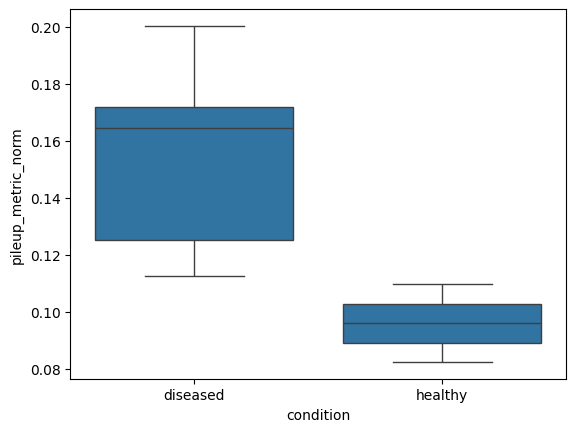

In [ ]:
df_metrics_s = df_metrics.groupby("sample")[["n_pre_umis", "n_post_umis"]].sum()

pre_width = int(SVA_START_BP) - int(INTRON32_FIRST_BP)
post_width = int(POST_END) - int(POST_START)   # must match the window n_post_umis was counted over

df_metrics_s["pileup_metric"] = df_metrics_s["n_pre_umis"] / (df_metrics_s["n_pre_umis"] + df_metrics_s["n_post_umis"])
df_metrics_s["pre_density"] = df_metrics_s["n_pre_umis"] / pre_width
df_metrics_s["post_density"] = df_metrics_s["n_post_umis"] / post_width
df_metrics_s["pileup_metric_norm"] = df_metrics_s["pre_density"] / (df_metrics_s["pre_density"] + df_metrics_s["post_density"])



df_metrics_s = df_metrics_s.merge(df_sample_meta, left_index=True, right_on="donor_number")

display(df_metrics_s)

sns.boxplot(
    data=df_metrics_s.reset_index(),
    x="condition",
    y="pileup_metric",
    #hue="condition"
); plt.show()

sns.boxplot(
    data=df_metrics_s.reset_index(),
    x="condition",
    y="pileup_metric_norm",
    #hue="condition"
); plt.show()


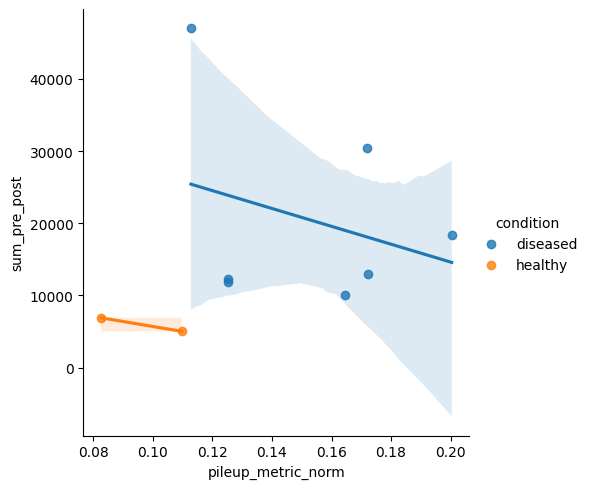

In [ ]:
#correlates with total library size at all
df_metrics_s["sum_pre_post"] = df_metrics_s["n_pre_umis"] + df_metrics_s["n_post_umis"]
sns.lmplot(df_metrics_s, x="pileup_metric_norm", y="sum_pre_post", hue="condition")

# Save bam file H and D jsut taf1 merged

In [ ]:
df_libraries

,entity:library_id,donor_number,donor_id,condition,sex,age_at_onset,age_at_death,bcl,RNAindex,SBindex,...,cellranger_count_h5,terra_slidetag,terra_cellbender,terra_dropsift,script_01_adata,script_02_mmc,script_03_QC,script_04_merge,script_05_zone (4 / 6),script_06_ct_for_deg
3,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B10,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B10,SI-TT-A11,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN
4,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B11,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B11,SI-TT-A12,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN
5,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B12,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B12,SI-TT-B1,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN
6,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C1,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C1,SI-TT-B2,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN


In [ ]:
import subprocess, os
from pathlib import Path

# ---------------------------------------------------------------------------
# Adjust to match your df_libraries table
# ---------------------------------------------------------------------------
GROUP_COLUMN  = "condition"   # column that flags healthy vs disease
HEALTHY_LABEL = "healthy"
DISEASE_LABEL = "diseased"

BASE = os.path.expandvars(
    "$HOME/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries"
)
MERGED_DIR = f"/home/gdallagl/myworkdir/XDP/data/_old/merged"
os.makedirs(MERGED_DIR, exist_ok=True)

def bam_path(row):
    lib, bcl, sample = row["RNAindex"], row["bcl"], row["donor_number"]
    return f"{BASE}/{sample}/{bcl}/{lib}/bam/taf1_subset.bam"

healthy_bams = [bam_path(r) for _, r in df_libraries.iterrows() if r[GROUP_COLUMN] == HEALTHY_LABEL]
disease_bams = [bam_path(r) for _, r in df_libraries.iterrows() if r[GROUP_COLUMN] == DISEASE_LABEL]

missing = [p for p in healthy_bams + disease_bams if not Path(p).exists()]
if missing:
    print("WARNING - missing bam files (skipped):")
    for p in missing:
        print(" ", p)
healthy_bams = [p for p in healthy_bams if Path(p).exists()]
disease_bams = [p for p in disease_bams if Path(p).exists()]

def merge_group(bam_list, out_name):
    if not bam_list:
        print(f"No bams found for {out_name}, skipping.")
        return
    out_bam = f"{MERGED_DIR}/{out_name}.bam"
    proc = subprocess.run(
        ["samtools", "merge", "-f", out_bam] + bam_list,
        capture_output=True, text=True
    )
    if proc.returncode != 0:
        print(f"FAILED merging {out_name}:\n{proc.stderr}")
        return
    subprocess.run(["samtools", "index", out_bam], check=True)
    print(f"Merged {len(bam_list)} bams -> {out_bam}")

merge_group(healthy_bams, "healthy_merged")
merge_group(disease_bams, "disease_merged")

Merged 6 bams -> /home/gdallagl/myworkdir/XDP/data/_old/merged/healthy_merged.bam
Merged 31 bams -> /home/gdallagl/myworkdir/XDP/data/_old/merged/disease_merged.bam


In [ ]:
healthy_bams

[]

# TAF1 intron-32 / cryptic exon quantification

### Verigy wher egene and exons are in ref geneome


genome used: gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/references/refdata-gex-GRCh38-2024-A/genes/

In [ ]:
%%bash

GTF=/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/genome_fasta/refdata-gex-GRCh38-2024-A/genes/genes.gtf.gz
GTF_SUBSET_ALL_TAF1_TRANSCRIPTS=/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/genome_fasta/refdata-gex-GRCh38-2024-A/genes/taf1_region.gtf
GTF_SUBSET_CANONICAL_TAF1=/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/genome_fasta/refdata-gex-GRCh38-2024-A/genes/taf1_canonical.gtf

# create subset version with all TAF1 transcripts
zcat $GTF | awk '$0 ~ /^#/ || ($1=="chrX" && $4 >= 71360000 && $5 <= 71540000)' > "$GTF_SUBSET_ALL_TAF1_TRANSCRIPTS"

# create subset with only the canonical transcript (ENST00000423759, TAF1-204)
grep -v "^#" "$GTF_SUBSET_ALL_TAF1_TRANSCRIPTS" | grep 'transcript_id "ENST00000423759"' > "$GTF_SUBSET_CANONICAL_TAF1"

# gene span
zcat "$GTF" | awk -F'\t' '$3=="gene"' | grep 'gene_name "TAF1"'

# exons of the MANE Select / canonical transcript
zcat "$GTF" | awk -F'\t' '$3=="exon"' | grep 'gene_name "TAF1"' | grep 'transcript_id "ENST00000423759' | tail -n 5


chrX	HAVANA	gene	71366222	71532374	.	+	.	gene_id "ENSG00000147133"; gene_version "17"; gene_type "protein_coding"; gene_name "TAF1"; level 1; hgnc_id "HGNC:11535"; tag "ncRNA_host"; havana_gene "OTTHUMG00000022723.7";
chrX	HAVANA	exon	71454741	71454857	.	+	.	gene_id "ENSG00000147133"; gene_version "17"; transcript_id "ENST00000423759"; transcript_version "6"; gene_type "protein_coding"; gene_name "TAF1"; transcript_type "protein_coding"; transcript_name "TAF1-204"; exon_number 34; exon_id "ENSE00003631125"; exon_version "1"; level 2; protein_id "ENSP00000406549.2"; transcript_support_level "5"; hgnc_id "HGNC:11535"; tag "CAGE_supported_TSS"; tag "upstream_ATG"; tag "basic"; tag "Ensembl_canonical"; tag "MANE_Select"; tag "appris_principal_4"; tag "CCDS"; ccdsid "CCDS14412.2"; havana_gene "OTTHUMG00000022723.7"; havana_transcript "OTTHUMT00000058996.3";
chrX	HAVANA	exon	71458241	71458366	.	+	.	gene_id "ENSG00000147133"; gene_version "17"; transcript_id "ENST00000423759"; transcript_vers

In [ ]:
REGIONS = {
    "taf1_gene":       ("chrX", 71366131, 71532374), # https://www.genecards.org/card/TAF1#Genomics
    "exon32":          ("chrX", 71424154, 71424238), # https://www.genecards.org/card/TAF1#Genomics
    "exon33":          ("chrX", 71454170, 71454237), # https://www.genecards.org/card/TAF1#Genomics
    "intron32":        ("chrX", 71424239, 71454169), # subtraction
    "exon34":          ("chrX", 71454741, 71454857), # https://www.genecards.org/card/TAF1#Genomics

    # from ex32 to right before SVA
    "retain_32i":      ("chrX", 71424239, 71440488), # ZNF91 paper - "Analysis of RNA Sequencing Data": https://pmc.ncbi.nlm.nih.gov/articles/PMC11331120/#s10 (TAF1_partialTAF1_intron32, chrX:71424239-71440488)
    "pre_SVA":         ("chrX", 71366131, 71440488), # based on rest: start taf1 - start SVA
    "post_SVA":        ("chrX", 71440488, 71532374), # based on rest: start SVA - end taf1
    # criptic exons inside "reatain_32i": after ex23 and befoee SVA
    "cryptic_32i_window": ("chrX", 71438000, 71440488),  # approximate;
    #"cryptic_32i":     ("chrX", , ), 

    # total exons
    # total introns
    # SVA site --> not possibel in referecne genome
}

In [ ]:
%%bash
BAM="/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam"

# tally counted molecules by region (E/N/I)
samtools view -e '[xf]==25' "$BAM" 2>/dev/null \
  | grep -oP 'RE:A:\K[ENI]' \
  | sort | uniq -c

  32379 E
  25127 N


In [ ]:
!samtools view -c -e '[xf]==25' /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam chrX:71366131-71532374

!samtools view -c -e '[xf]==25 && [RE]=="E"' /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam chrX:71366131-71532374

!samtools view -e '[xf]==25' /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam | grep -oP 'RE:A:\K[ENI]' | sort | uniq -c


26108


8686
  32379 E
  25127 N
